#0. Ejecutar al iniciar

In [30]:
from google.colab import drive
import os

drive.mount('/content/drive')
mi_ruta = '/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto/AcneDataset/train'
os.chdir(mi_ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Librerias para el procesamiento de las imagenes

In [2]:
import cv2 # Para procesar imágenes (grises, rotación)
import numpy as np # Para cálculos estadísticos
import matplotlib.pyplot as plt # Para ver las fotos y gráficas
import seaborn as sns # Para que tus gráficas de color se vean profesionales
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

# 1.Descarga de imaganes

Vincular Drive con Colab

In [3]:
from google.colab import drive
import os

# 1. Montamos el Drive (Paso obligatorio)
drive.mount('/content/drive')

# 2. Definimos TU ubicación personalizada
# Cambia 'Clase_IA/Dataset_Acne' por el nombre de las carpetas que prefieras
mi_ruta_personalizada = '/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto'

# 3. Creamos la carpeta si no existe
if not os.path.exists(mi_ruta_personalizada):
    os.makedirs(mi_ruta_personalizada)
    print(f"Carpeta creada en: {mi_ruta_personalizada}")

# 4. Nos movemos a esa ubicación
%cd $mi_ruta_personalizada

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto


Configurar las credenciales de Kaggle

In [31]:
# REEMPLAZA ESTOS DATOS
os.environ['KAGGLE_USERNAME'] = "hjfuis"
os.environ['KAGGLE_KEY'] = "KGAT_7067e701e235e3e2e8508df6820a675d"

# Esto crea el archivo automáticamente en la ubicación correcta
!mkdir -p ~/.kaggle
import json
data = {"username":os.environ['KAGGLE_USERNAME'], "key":os.environ['KAGGLE_KEY']}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(data, f)

!chmod 600 /root/.kaggle/kaggle.json
print("Archivo kaggle.json creado exitosamente.")

Archivo kaggle.json creado exitosamente.


Descargar y descomprimir el dataset en tu carpeta de Drive

In [28]:
# 1. Define tu carpeta del proyecto (Cámbiala si prefieres otro nombre)
!mkdir -p "$mi_ruta_personalizada"
%cd "$mi_ruta_personalizada"

# 2. Descarga el dataset desde Kaggle
!kaggle datasets download -d tiswan14/acne-dataset-image

# 3. Descomprime (el parámetro -q lo hace en silencio y más rápido)
!unzip -q acne-dataset-image.zip
!rm acne-dataset-image.zip  # Borra el zip para ahorrar espacio en Drive
print("¡Hecho! Los archivos están en tu Drive.")

/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto
Dataset URL: https://www.kaggle.com/datasets/tiswan14/acne-dataset-image
License(s): apache-2.0
100% 122M/122M [00:07<00:00, 18.0MB/s]

replace AcneDataset/test/Blackheads/blackhead-1-_JPG_jpg.rf.d7b8a53aebb5da67b8acd0f8498ae9a3.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A

A

¡Hecho! Los archivos están en tu Drive.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2.Validación del Dataset

In [32]:
# Configuración de estética "Premium"
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

Verificación el contenido

In [33]:
# Listar las carpetas (clases) y contar imágenes
categorias = [f for f in os.listdir('.') if os.path.isdir(f)]
conteo = {cat: len(os.listdir(cat)) for cat in categorias}

# Mostrar en una tabla simple
df_stats = pd.DataFrame(conteo.items(), columns=['Nivel de Acné', 'Cantidad de Imágenes'])
print(df_stats)

  Nivel de Acné  Cantidad de Imágenes
0    Blackheads                   735
1          Cyst                   645
2       Papules                   621
3      Pustules                   584
4    Whiteheads                   193


Análisis de Píxeles

In [7]:
dimensiones = []
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(root, file)
            img = cv2.imread(path)
            if img is not None:
                h, w, c = img.shape
                # Guardamos alto, ancho y la categoría (nombre de la carpeta)
                categoria = os.path.basename(root)
                dimensiones.append({'Categoria': categoria, 'Alto': h, 'Ancho': w, 'Pixeles_Totales': h*w})

df_dim = pd.DataFrame(dimensiones)

# Resumen estadístico para tu presentación
print("Resumen de dimensiones del dataset:")
print(df_dim.groupby('Categoria')[['Alto', 'Ancho']].describe())

Resumen de dimensiones del dataset:
              Alto                                                  Ancho  \
             count   mean  std    min    25%    50%    75%    max   count   
Categoria                                                                   
Blackheads  1240.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  1240.0   
Cyst        1040.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  1040.0   
Papules     1032.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  1032.0   
Pustules    1006.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  1006.0   
Whiteheads   299.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0   299.0   

                                                           
             mean  std    min    25%    50%    75%    max  
Categoria                                                  
Blackheads  640.0  0.0  640.0  640.0  640.0  640.0  640.0  
Cyst        640.0  0.0  640.0  640.0  640.0  640.0  640.0  
Papules     640.0  0.0  640.0  640.0  640.0  64

Extracción de Datos

In [8]:
def extraer_datos_proyecto(ruta_base, categorias, n_muestras=50):
    recolector = []

    for cat in categorias:
        folder = os.path.join(ruta_base, cat)
        if not os.path.isdir(folder): continue

        # Tomamos una muestra para que el proceso sea rápido
        imagenes = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png', '.jpeg'))][:n_muestras]

        for img_name in imagenes:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                # 1. Color Promedio (RGB)
                avg_color = np.mean(img, axis=(0, 1))
                # 2. Contraste (Varianza en escala de grises)
                gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                contraste = np.var(gris)

                recolector.append({
                    'Categoria': cat,
                    'Rojo': avg_color[2],
                    'Verde': avg_color[1],
                    'Azul': avg_color[0],
                    'Contraste': contraste
                })

    return pd.DataFrame(recolector)

# --- EJECUCIÓN ---
# Asegúrate de que mi_ruta apunte a '.../AcneDataset/train'
categorias_acne = [f for f in os.listdir(mi_ruta) if os.path.isdir(os.path.join(mi_ruta, f))]
df_proyecto = extraer_datos_proyecto(mi_ruta, categorias_acne)

print("Datos extraídos con éxito. Filas generadas:", len(df_proyecto))

Datos extraídos con éxito. Filas generadas: 250


Distribución de Color (Análisis por Patología)

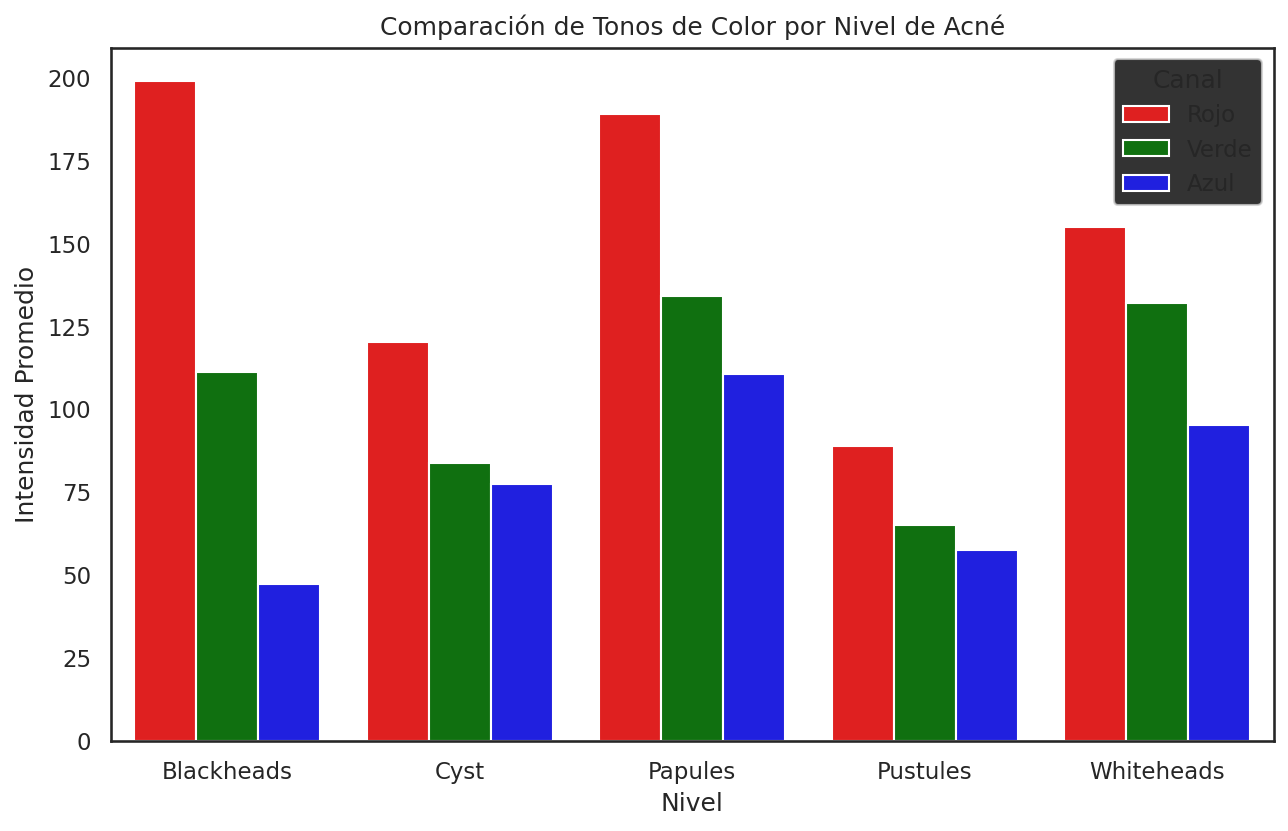

In [20]:
def analizar_color(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Calculamos el promedio de cada canal (R, G, B)
    promedios = np.mean(img, axis=(0, 1))
    return promedios

# Tomamos una muestra de cada categoría para comparar
resultados_color = []
for cat in categorias:
    carpeta_cat = os.path.join(mi_ruta, cat)
    primera_img = os.path.join(carpeta_cat, os.listdir(carpeta_cat)[0])
    r, g, b = analizar_color(primera_img)
    resultados_color.append({'Nivel': cat, 'Rojo': r, 'Verde': g, 'Azul': b})

df_color = pd.DataFrame(resultados_color)

# Graficar para el avance del proyecto
plt.figure(figsize=(10, 6))
df_melt = df_color.melt(id_vars='Nivel', var_name='Canal', value_name='Intensidad Promedio')
sns.barplot(data=df_melt, x='Nivel', y='Intensidad Promedio', hue='Canal', palette=['red', 'green', 'blue'])
plt.title("Comparación de Tonos de Color por Nivel de Acné")
plt.show()

Histogramas Comparativos de color

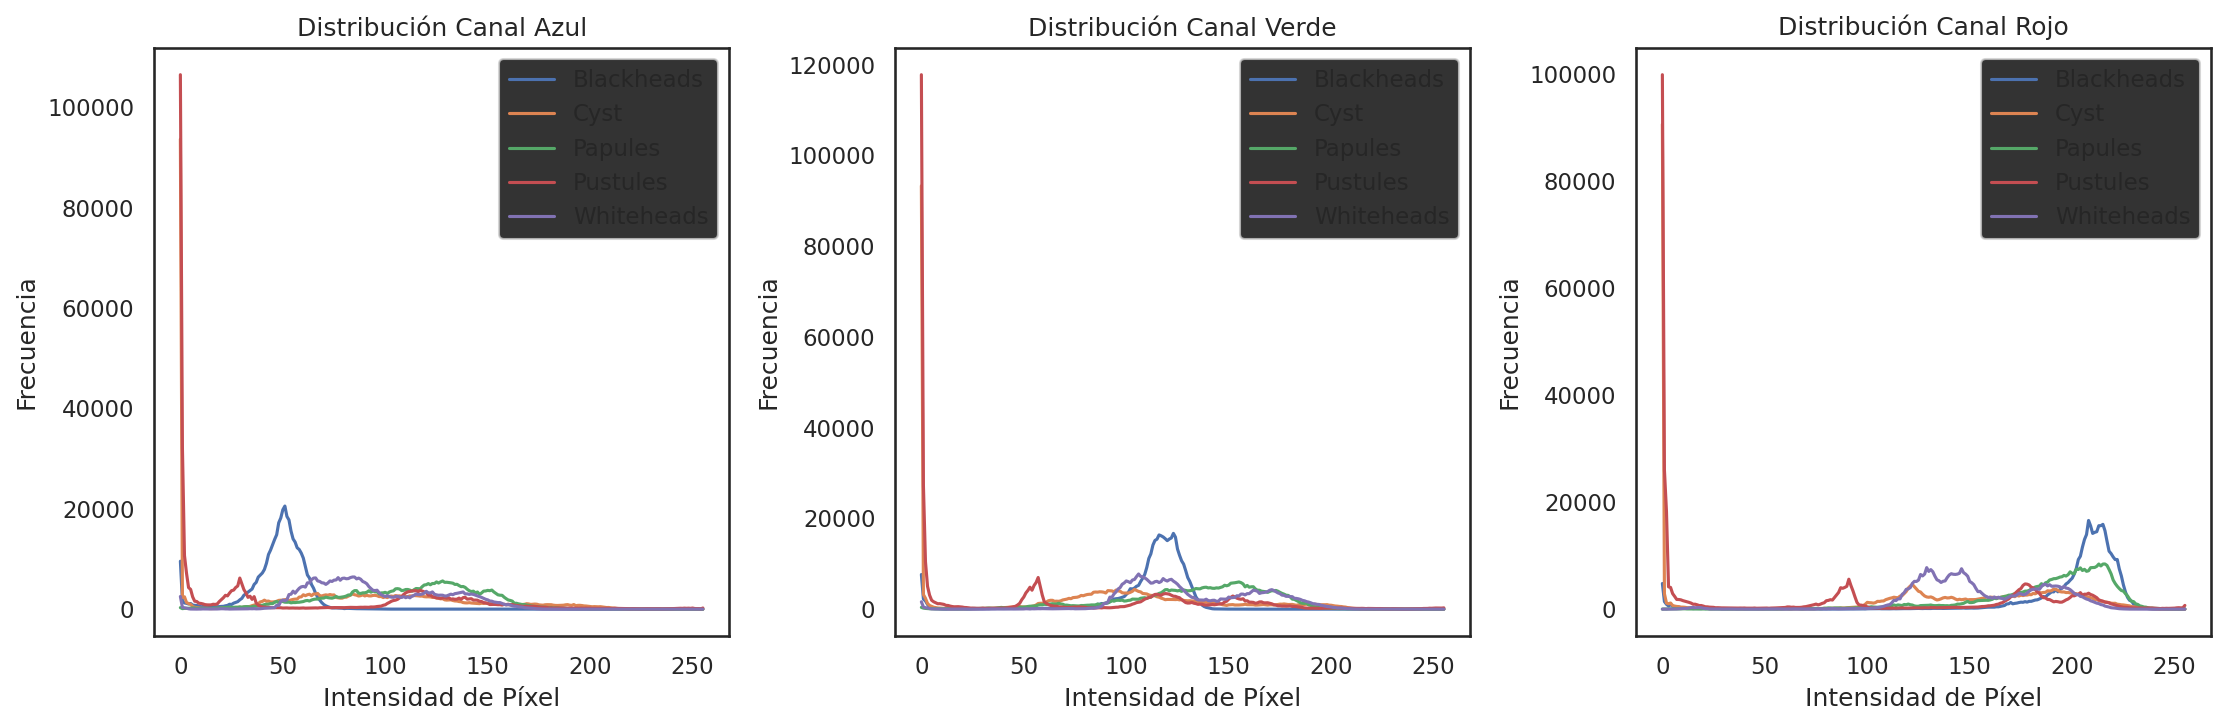

In [17]:
def graficar_comparativa_histogramas(ruta_base, categorias):
    plt.figure(figsize=(15, 5))
    colores = ('b', 'g', 'r')
    nombres_canales = ('Azul', 'Verde', 'Rojo')

    for i, col in enumerate(colores):
        plt.subplot(1, 3, i+1)
        for cat in categorias:
            # Tomamos una imagen representativa de cada carpeta
            folder = os.path.join(ruta_base, cat)
            img_name = os.listdir(folder)[0]
            img = cv2.imread(os.path.join(folder, img_name))

            # Calcular histograma para el canal actual
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            plt.plot(hist, label=cat)

        plt.title(f'Distribución Canal {nombres_canales[i]}')
        plt.xlabel('Intensidad de Píxel')
        plt.ylabel('Frecuencia')
        plt.legend()

    plt.tight_layout()
    plt.show()

categorias = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
graficar_comparativa_histogramas(mi_ruta, categorias)

In [34]:
def grafico_distribucion_clara(df):
    # Agregamos sharex=False y sharey=False para que Seaborn las trate como gráficas independientes
    g = sns.FacetGrid(df, col="Categoria", hue="Categoria", col_wrap=3,
                      palette="rocket", height=3.5, aspect=1.3, sharex=False, sharey=False)

    # Dibujamos la densidad
    g.map(sns.kdeplot, "Rojo", fill=True, alpha=0.7, linewidth=2)

    # Títulos individuales
    g.set_titles("{col_name}", fontweight='bold', size=13)

    # --- LA SOLUCIÓN DEFINITIVA ---
    for ax in g.axes.flatten():
        ax.set_xlim(0, 255) # Límite real del color
        # Forzamos los textos en CADA una de las gráficas
        ax.set_xlabel("Intensidad Roja (0-255)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Densidad", fontsize=11)
    # ------------------------------

    # Aumentamos wspace (espacio horizontal) y hspace (vertical) para que los textos no choquen
    plt.subplots_adjust(top=0.88, hspace=0.6, wspace=0.4)

    g.fig.suptitle('Distribución del Canal Rojo por Tipo de Acné', fontsize=16, fontweight='bold')
    plt.show()

grafico_distribucion_clara(df_proyecto)

KeyError: 'Categoria'

Boxplots de Intensidad por Canal

In [35]:
def grafico_violin_impacto(df):
    plt.figure(figsize=(10, 5))

    # El violín muestra la densidad
    sns.violinplot(data=df, x='Categoria', y='Rojo', inner=None, palette="rocket", alpha=0.6)

    # Superponemos los puntos reales (jitter) para ver la muestra completa
    sns.stripplot(data=df, x='Categoria', y='Rojo', color="white", edgecolor="black",
                  size=3, alpha=0.3, jitter=True)

    plt.title("Distribución de Intensidad: Análisis de Variabilidad", fontsize=15, pad=20)
    plt.xlabel("Categoría de Acné", fontsize=12)
    plt.ylabel("Intensidad Canal Rojo", fontsize=12)
    sns.despine(trim=True, left=True)
    plt.show()

grafico_violin_impacto(df_proyecto)

ValueError: Could not interpret value `Categoria` for `x`. An entry with this name does not appear in `data`.

<Figure size 1500x750 with 0 Axes>

Análisis de Contraste (Varianza de Grises)

/tmp/ipykernel_15576/1998093549.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Categoria', y='Contraste', data=df_cont, palette="Greys_r")


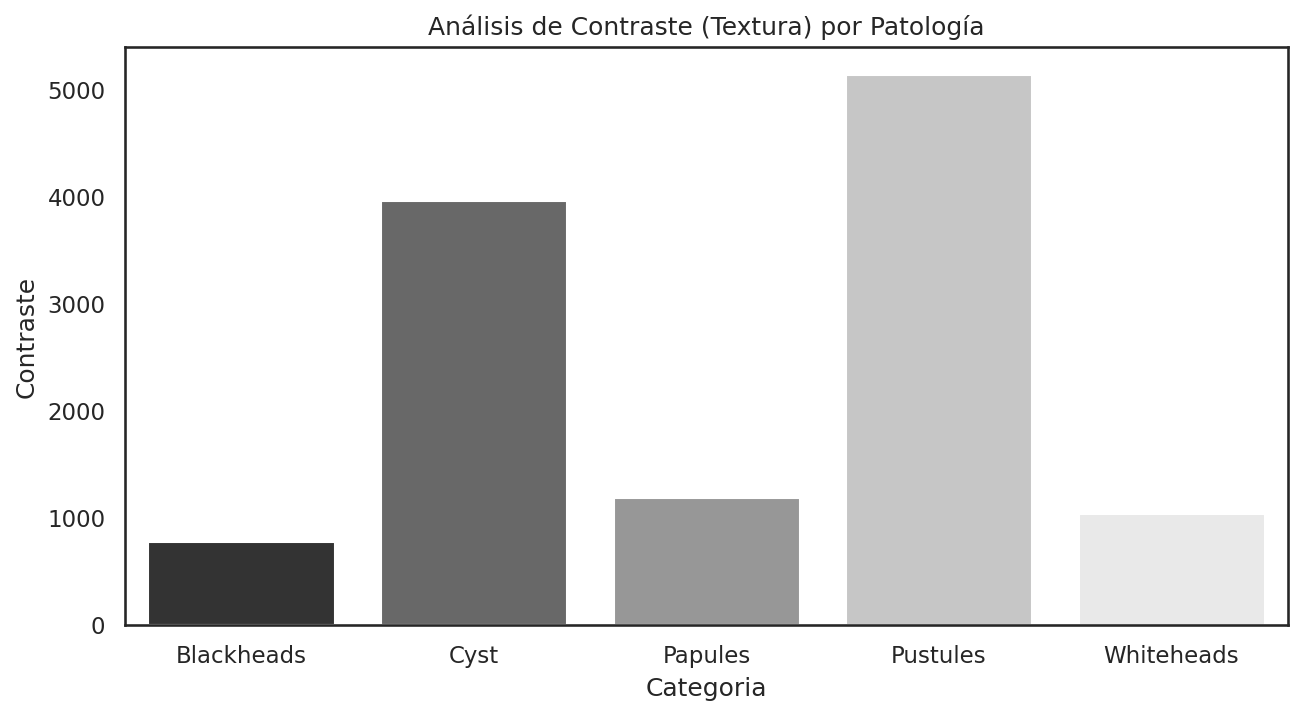

In [12]:
def analizar_contraste(ruta_datos, categorias):
    contraste_resultados = []

    for cat in categorias:
        folder = os.path.join(ruta_datos, cat)
        img_name = os.listdir(folder)[0]
        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)

        # La varianza es una medida de contraste
        varianza = np.var(img)
        contraste_resultados.append({'Categoria': cat, 'Contraste': varianza})

    df_cont = pd.DataFrame(contraste_resultados)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Categoria', y='Contraste', data=df_cont, palette="Greys_r")
    plt.title('Análisis de Contraste (Textura) por Patología')
    plt.show()

analizar_contraste(mi_ruta, categorias)

In [36]:
def grafico_heatmap_correlacion(df):
    # Agrupamos por categoría y sacamos el promedio
    df_resumen = df.groupby('Categoria').mean()

    # Normalizamos para que la comparación sea visualmente clara (0 a 1)
    df_norm = (df_resumen - df_resumen.min()) / (df_resumen.max() - df_resumen.min())

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_norm, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=.5)

    plt.title("Mapa de Correlación: Características vs Patologías", fontsize=15, pad=20)
    plt.ylabel("Tipo de Acné")
    plt.show()

grafico_heatmap_correlacion(df_proyecto)

KeyError: 'Categoria'

Visualización de Procesamiento (Original vs. Transformada)

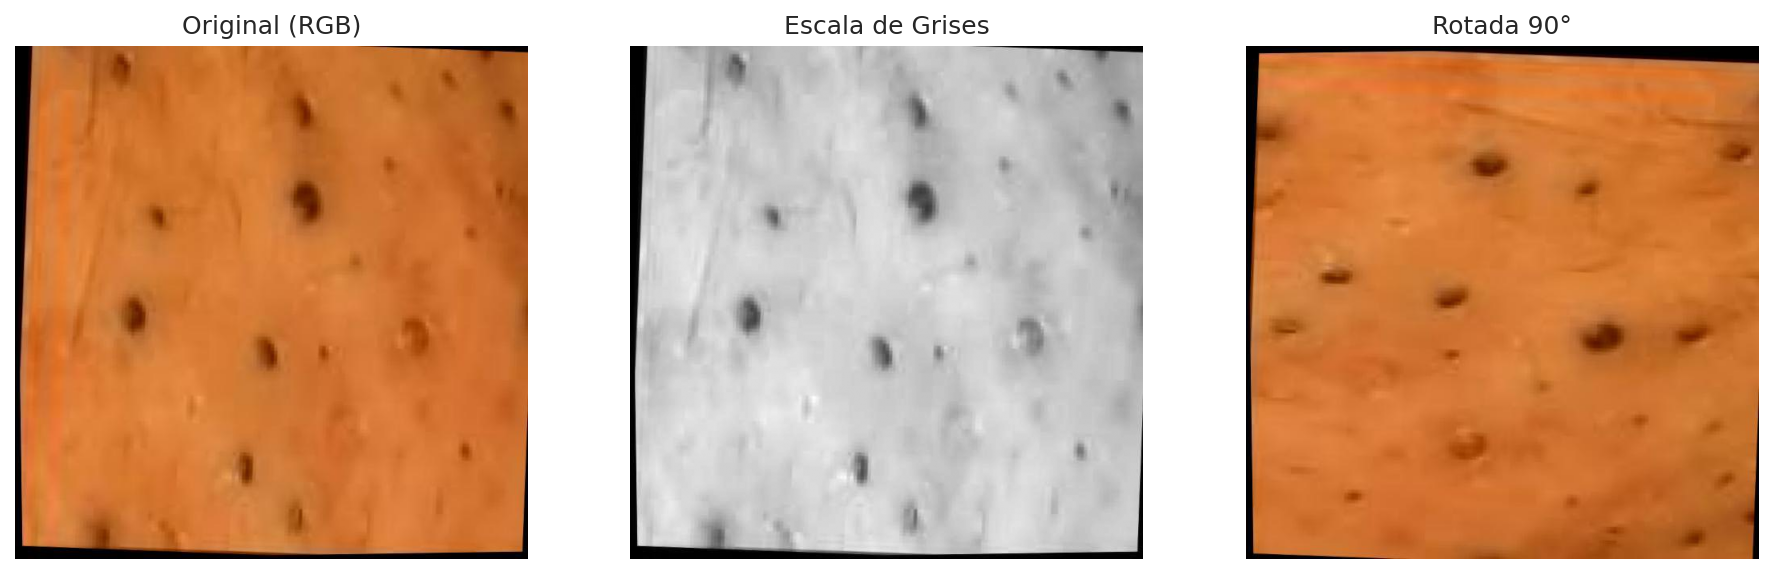

In [37]:
# Elegir una imagen de prueba
img_prueba_path = os.path.join(mi_ruta, categorias[0], os.listdir(categorias[0])[0])
img_original = cv2.imread(img_prueba_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Procesamiento
img_gris = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)
img_rotada = cv2.rotate(img_original, cv2.ROTATE_90_CLOCKWISE)

# Mostrar resultados en una sola fila
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_original)
ax[0].set_title("Original (RGB)")
ax[1].imshow(img_gris, cmap='gray')
ax[1].set_title("Escala de Grises")
ax[2].imshow(img_rotada)
ax[2].set_title("Rotada 90°")
for a in ax: a.axis('off')
plt.show()

# 3. selección de datos

0. Construir el DataFrame con las etiquetas

In [38]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import local_binary_pattern
from scipy.stats import entropy

data = []

for etiqueta in os.listdir('.'):
    if os.path.isdir(etiqueta):
        for archivo in os.listdir(etiqueta):
            if archivo.endswith(('.jpg', '.png')):
                ruta_completa = os.path.join(etiqueta, archivo)
                img_bgr = cv2.imread(ruta_completa)

                if img_bgr is None:
                    continue

                # ── RGB ──────────────────────────────────────────────
                rojo   = np.mean(img_bgr[:, :, 2])
                verde  = np.mean(img_bgr[:, :, 1])
                azul   = np.mean(img_bgr[:, :, 0])
                contraste = img_bgr.std()

                # ── HSV (detecta inflamación y saturación) ────────────
                img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
                hue_mean = np.mean(img_hsv[:, :, 0])
                sat_mean = np.mean(img_hsv[:, :, 1])
                val_mean = np.mean(img_hsv[:, :, 2])

                # ── LBP — Local Binary Patterns (textura) ─────────────
                gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                lbp  = local_binary_pattern(gris, P=8, R=1, method='uniform')
                lbp_hist, _ = np.histogram(lbp.ravel(),
                                           bins=np.arange(0, 11),
                                           density=True)
                lbp_mean = np.mean(lbp)

                # ── Entropía (rugosidad / complejidad visual) ──────────
                # Histograma de la imagen en escala de grises → entropía
                hist_gris, _ = np.histogram(gris.ravel(), bins=256,
                                            range=(0, 256), density=True)
                hist_gris += 1e-10          # evitar log(0)
                entropia = entropy(hist_gris)

                data.append({
                    'Etiqueta'  : etiqueta,
                    'Rojo'      : rojo,
                    'Verde'     : verde,
                    'Azul'      : azul,
                    'Contraste' : contraste,
                    'Hue'       : hue_mean,
                    'Saturacion': sat_mean,
                    'Valor_HSV' : val_mean,
                    'LBP_Mean'  : lbp_mean,
                    'Entropia'  : entropia,
                })

df_proyecto = pd.DataFrame(data)
print(f"Dataset inicial: {df_proyecto.shape}")
print(df_proyecto['Etiqueta'].value_counts())

Dataset inicial: (2778, 10)
Etiqueta
Blackheads    735
Cyst          645
Papules       621
Pustules      584
Whiteheads    193
Name: count, dtype: int64


1. Preparación y Limpieza (Isolation Forest + Z-Score).
En este bloque se aplica un escalado y el manejo de etiquetas. Para los valores atípicos (outliers), se usa el método de Rango Intercuartílico (IQR) en las características de color para asegurar que fotos con iluminación extrema no sesguen el modelo.

In [39]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from scipy import stats

# ── Encoding de etiquetas ─────────────────────────────────────────────────────
le = LabelEncoder()
df_proyecto['Etiqueta_Num'] = le.fit_transform(df_proyecto['Etiqueta'])
print("Clases codificadas:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Columnas numéricas completas ──────────────────────────────────────────────
columnas_numericas = ['Rojo', 'Verde', 'Azul', 'Contraste',
                      'Hue', 'Saturacion', 'Valor_HSV', 'LBP_Mean', 'Entropia']

# ── Método 1: Z-Score (elimina muestras con z > 3 en CUALQUIER feature) ───────
z_scores  = np.abs(stats.zscore(df_proyecto[columnas_numericas]))
mascara_z = (z_scores < 3).all(axis=1)          # True = fila limpia

df_zscore = df_proyecto[mascara_z].copy()
print(f"\n[Z-Score] Originales: {len(df_proyecto)} | "
      f"Limpias: {len(df_zscore)} | "
      f"Removidas: {len(df_proyecto) - len(df_zscore)}")

# ── Método 2: Isolation Forest (detecta combinaciones anómalas) ───────────────
iso = IsolationForest(contamination=0.05,   # asume ~5 % de outliers
                      random_state=42,
                      n_estimators=100)

pred_iso = iso.fit_predict(df_proyecto[columnas_numericas])
mascara_iso = pred_iso == 1                  # 1 = inlier, -1 = outlier

df_iso    = df_proyecto[mascara_iso].copy()
print(f"[Isolation Forest] Originales: {len(df_proyecto)} | "
      f"Limpias: {len(df_iso)} | "
      f"Removidas: {len(df_proyecto) - len(df_iso)}")

# ── Elegimos el dataset limpio final (usamos Isolation Forest como principal) ──
# Puedes cambiar a df_zscore si prefieres Z-Score
df_clean = df_iso.reset_index(drop=True)
print(f"\nDataset final para modelado: {df_clean.shape}")
print(df_clean['Etiqueta'].value_counts())

Clases codificadas: {'Blackheads': np.int64(0), 'Cyst': np.int64(1), 'Papules': np.int64(2), 'Pustules': np.int64(3), 'Whiteheads': np.int64(4)}

[Z-Score] Originales: 2778 | Limpias: 2623 | Removidas: 155
[Isolation Forest] Originales: 2778 | Limpias: 2639 | Removidas: 139

Dataset final para modelado: (2639, 11)
Etiqueta
Blackheads    703
Cyst          631
Papules       611
Pustules      576
Whiteheads    118
Name: count, dtype: int64


2. Escalamiento y Selección de Características.
Para cumplir con el requisito de "método formal", utilizaremos SelectKBest con la prueba ANOVA. Esto generará una gráfica excelente para tus diapositivas sobre qué colores influyen más en la detección.

Dimensiones: X_scaled=(2639, 9) | y_clean=(2639,)

Ranking de características:
   Feature   F_Score      P_Value
  LBP_Mean 87.638505 5.333369e-70
  Entropia 34.887695 1.996110e-28
Saturacion 26.224968 2.368551e-21
 Contraste 19.879127 3.857716e-16
       Hue 10.219275 3.285824e-08
      Rojo  5.621722 1.668300e-04
 Valor_HSV  5.579343 1.802122e-04
      Azul  3.763469 4.666669e-03
     Verde  0.685918 6.016615e-01


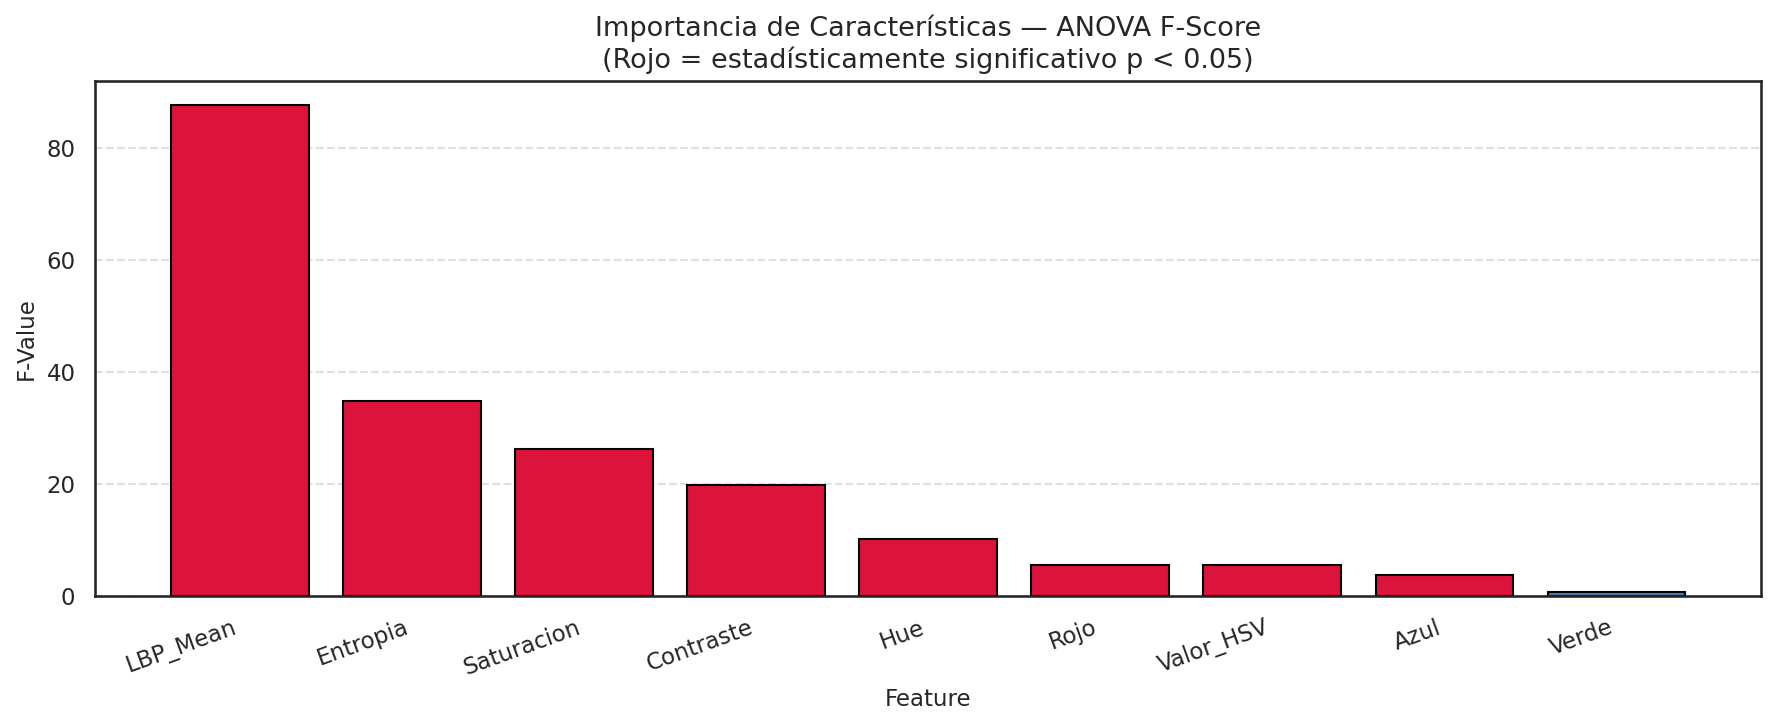


Features seleccionadas (k=5): [np.str_('Contraste'), np.str_('Hue'), np.str_('Saturacion'), np.str_('LBP_Mean'), np.str_('Entropia')]
X_final shape: (2639, 5)


In [40]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

# ── Separamos X y y SIEMPRE desde df_clean ────────────────────────────────────
X_clean = df_clean[columnas_numericas]          # features
y_clean = df_clean['Etiqueta_Num']              # target (numérico)

# ── Escalamiento con RobustScaler (más robusto ante los outliers residuales) ──
# También puedes usar StandardScaler; ambos cumplen el requerimiento
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X_clean)

print(f"Dimensiones: X_scaled={X_scaled.shape} | y_clean={y_clean.shape}")
# ▲ Deben coincidir — este era tu error: antes usabas 'y' (df_proyecto) en vez de y_clean

# ── SelectKBest con ANOVA ─────────────────────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y_clean)          # ← y_clean, NO y

# ── Visualización de importancia ──────────────────────────────────────────────
scores_df = pd.DataFrame({
    'Feature': columnas_numericas,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nRanking de características:")
print(scores_df.to_string(index=False))

plt.figure(figsize=(12, 5))
colores = ['crimson' if p < 0.05 else 'steelblue'
           for p in scores_df['P_Value']]
plt.bar(scores_df['Feature'], scores_df['F_Score'],
        color=colores, edgecolor='black')
plt.title("Importancia de Características — ANOVA F-Score\n"
          "(Rojo = estadísticamente significativo p < 0.05)", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("F-Value", fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Seleccionamos las K mejores (ej. k=5) para el modelo final ────────────────
K_MEJOR = 5
selector_k = SelectKBest(score_func=f_classif, k=K_MEJOR)
X_final    = selector_k.fit_transform(X_scaled, y_clean)
features_seleccionadas = np.array(columnas_numericas)[selector_k.get_support()]

print(f"\nFeatures seleccionadas (k={K_MEJOR}): {list(features_seleccionadas)}")
print(f"X_final shape: {X_final.shape}")

3. Ajuste de Pesos para Clases Minoritarias. Esta es la parte clave que solicitaste. En lugar de borrar datos o inventar imágenes, le diremos al modelo que "preste más atención" (asigne más penalización al error) cuando se equivoque en categorías con pocas muestras, como Whiteheads.

In [41]:
from sklearn.utils.class_weight import compute_class_weight

# ── Calculamos sobre y_clean (dataset limpio), no sobre y original ────────────
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_clean),
    y=y_clean
)

dict_weights = {i: round(w, 4) for i, w in enumerate(weights)}

print("Pesos por clase:")
for clase_num, clase_nom in enumerate(le.classes_):
    print(f"  {clase_num} ({clase_nom:>15s}): {dict_weights[clase_num]:.4f}")

Pesos por clase:
  0 (     Blackheads): 0.7508
  1 (           Cyst): 0.8365
  2 (        Papules): 0.8638
  3 (       Pustules): 0.9163
  4 (     Whiteheads): 4.4729


4. Stratified K-Fold

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# ── Configuración del CV estratificado ───────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Modelo base con pesos de clase incorporados ───────────────────────────────
modelo = RandomForestClassifier(
    n_estimators=200,
    class_weight=dict_weights,   # manejo del desbalance
    random_state=42,
    n_jobs=-1
)

# ── Evaluación cruzada estratificada ─────────────────────────────────────────
scores = cross_val_score(
    modelo, X_final, y_clean,
    cv=skf,
    scoring='balanced_accuracy',   # métrica adecuada para desbalance
    n_jobs=-1
)

print(f"\nStratified K-Fold (k=5) — Balanced Accuracy por fold:")
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Media : {scores.mean():.4f}")
print(f"  Std   : {scores.std():.4f}")

# ── Verificación de estratificación (distribución por fold) ──────────────────
print("\nDistribución de clases por fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_clean), 1):
    dist = pd.Series(y_clean.iloc[val_idx]).value_counts().sort_index()
    print(f"  Fold {fold}: { {le.classes_[k]: v for k, v in dist.items()} }")


Stratified K-Fold (k=5) — Balanced Accuracy por fold:
  Fold 1: 0.7192
  Fold 2: 0.7632
  Fold 3: 0.7415
  Fold 4: 0.7481
  Fold 5: 0.7224

  Media : 0.7389
  Std   : 0.0164

Distribución de clases por fold:
  Fold 1: {'Blackheads': 141, 'Cyst': 126, 'Papules': 122, 'Pustules': 116, 'Whiteheads': 23}
  Fold 2: {'Blackheads': 141, 'Cyst': 126, 'Papules': 122, 'Pustules': 115, 'Whiteheads': 24}
  Fold 3: {'Blackheads': 141, 'Cyst': 126, 'Papules': 122, 'Pustules': 115, 'Whiteheads': 24}
  Fold 4: {'Blackheads': 140, 'Cyst': 127, 'Papules': 122, 'Pustules': 115, 'Whiteheads': 24}
  Fold 5: {'Blackheads': 140, 'Cyst': 126, 'Papules': 123, 'Pustules': 115, 'Whiteheads': 23}


In [43]:
import joblib

# ── Lo que tu compañero necesita para entrenar ────────────────────────────────

# 1. Arrays listos para el modelo
np.save('X_final.npy', X_final)       # (2639, 5) — features seleccionadas y escaladas
np.save('y_clean.npy', y_clean.values) # (2639,)  — etiquetas numéricas

# 2. Objetos de preprocesamiento (para que pueda transformar datos nuevos igual)
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(selector_k,  'selector_k.pkl')
joblib.dump(le,          'label_encoder.pkl')

# 3. Configuración del experimento
joblib.dump(dict_weights, 'class_weights.pkl')
joblib.dump(skf,          'stratified_kfold.pkl')

# 4. DataFrame completo por si necesita trazabilidad
df_clean.to_csv('df_clean.csv', index=False)

print("Archivos exportados:")
print("  X_final.npy       — Features para entrenar")
print("  y_clean.npy       — Etiquetas para entrenar")
print("  scaler.pkl        — Para escalar datos nuevos")
print("  selector_k.pkl    — Para seleccionar features en datos nuevos")
print("  label_encoder.pkl — Para decodificar predicciones a nombres")
print("  class_weights.pkl — Pesos para el modelo")
print("  stratified_kfold.pkl — Configuración del CV")
print("  df_clean.csv      — Dataset limpio completo")

Archivos exportados:
  X_final.npy       — Features para entrenar
  y_clean.npy       — Etiquetas para entrenar
  scaler.pkl        — Para escalar datos nuevos
  selector_k.pkl    — Para seleccionar features en datos nuevos
  label_encoder.pkl — Para decodificar predicciones a nombres
  class_weights.pkl — Pesos para el modelo
  stratified_kfold.pkl — Configuración del CV
  df_clean.csv      — Dataset limpio completo


In [44]:
import joblib

# ── Lo que tu compañero necesita para entrenar ────────────────────────────────

# 1. Arrays listos para el modelo
np.save('X_final.npy', X_final)       # (2639, 5) — features seleccionadas y escaladas
np.save('y_clean.npy', y_clean.values) # (2639,)  — etiquetas numéricas

# 2. Objetos de preprocesamiento (para que pueda transformar datos nuevos igual)
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(selector_k,  'selector_k.pkl')
joblib.dump(le,          'label_encoder.pkl')

# 3. Configuración del experimento
joblib.dump(dict_weights, 'class_weights.pkl')
joblib.dump(skf,          'stratified_kfold.pkl')

# 4. DataFrame completo por si necesita trazabilidad
df_clean.to_csv('df_clean.csv', index=False)

print("Archivos exportados:")
print("  X_final.npy       — Features para entrenar")
print("  y_clean.npy       — Etiquetas para entrenar")
print("  scaler.pkl        — Para escalar datos nuevos")
print("  selector_k.pkl    — Para seleccionar features en datos nuevos")
print("  label_encoder.pkl — Para decodificar predicciones a nombres")
print("  class_weights.pkl — Pesos para el modelo")
print("  stratified_kfold.pkl — Configuración del CV")
print("  df_clean.csv      — Dataset limpio completo")

Archivos exportados:
  X_final.npy       — Features para entrenar
  y_clean.npy       — Etiquetas para entrenar
  scaler.pkl        — Para escalar datos nuevos
  selector_k.pkl    — Para seleccionar features en datos nuevos
  label_encoder.pkl — Para decodificar predicciones a nombres
  class_weights.pkl — Pesos para el modelo
  stratified_kfold.pkl — Configuración del CV
  df_clean.csv      — Dataset limpio completo


# 4. Prueba de Modelos

Gauss Naive

In [45]:
import numpy as np
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

X = np.load('X_final.npy')
y = np.load('y_clean.npy')

le = joblib.load('label_encoder.pkl')
skf = joblib.load('stratified_kfold.pkl')

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", le.classes_)

Shape de X: (2639, 5)
Shape de y: (2639,)
Clases: ['Blackheads' 'Cyst' 'Papules' 'Pustules' 'Whiteheads']


In [46]:
acc_scores = []
bacc_scores = []

y_true_total = []
y_pred_total = []

fold = 1

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)

    acc_scores.append(acc)
    bacc_scores.append(bacc)

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

    print(f"Fold {fold}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Balanced Accuracy: {bacc:.4f}")
    print("-" * 35)

    fold += 1

Fold 1
  Accuracy: 0.4015
  Balanced Accuracy: 0.3626
-----------------------------------
Fold 2
  Accuracy: 0.3788
  Balanced Accuracy: 0.3249
-----------------------------------
Fold 3
  Accuracy: 0.3902
  Balanced Accuracy: 0.3411
-----------------------------------
Fold 4
  Accuracy: 0.3750
  Balanced Accuracy: 0.3268
-----------------------------------
Fold 5
  Accuracy: 0.3397
  Balanced Accuracy: 0.3055
-----------------------------------


In [47]:
print("Resultados globales - Gaussian Naive Bayes")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - Gaussian Naive Bayes
Accuracy promedio: 0.3770
Desviación estándar Accuracy: 0.0209
Balanced Accuracy promedio: 0.3322
Desviación estándar Balanced Accuracy: 0.0190


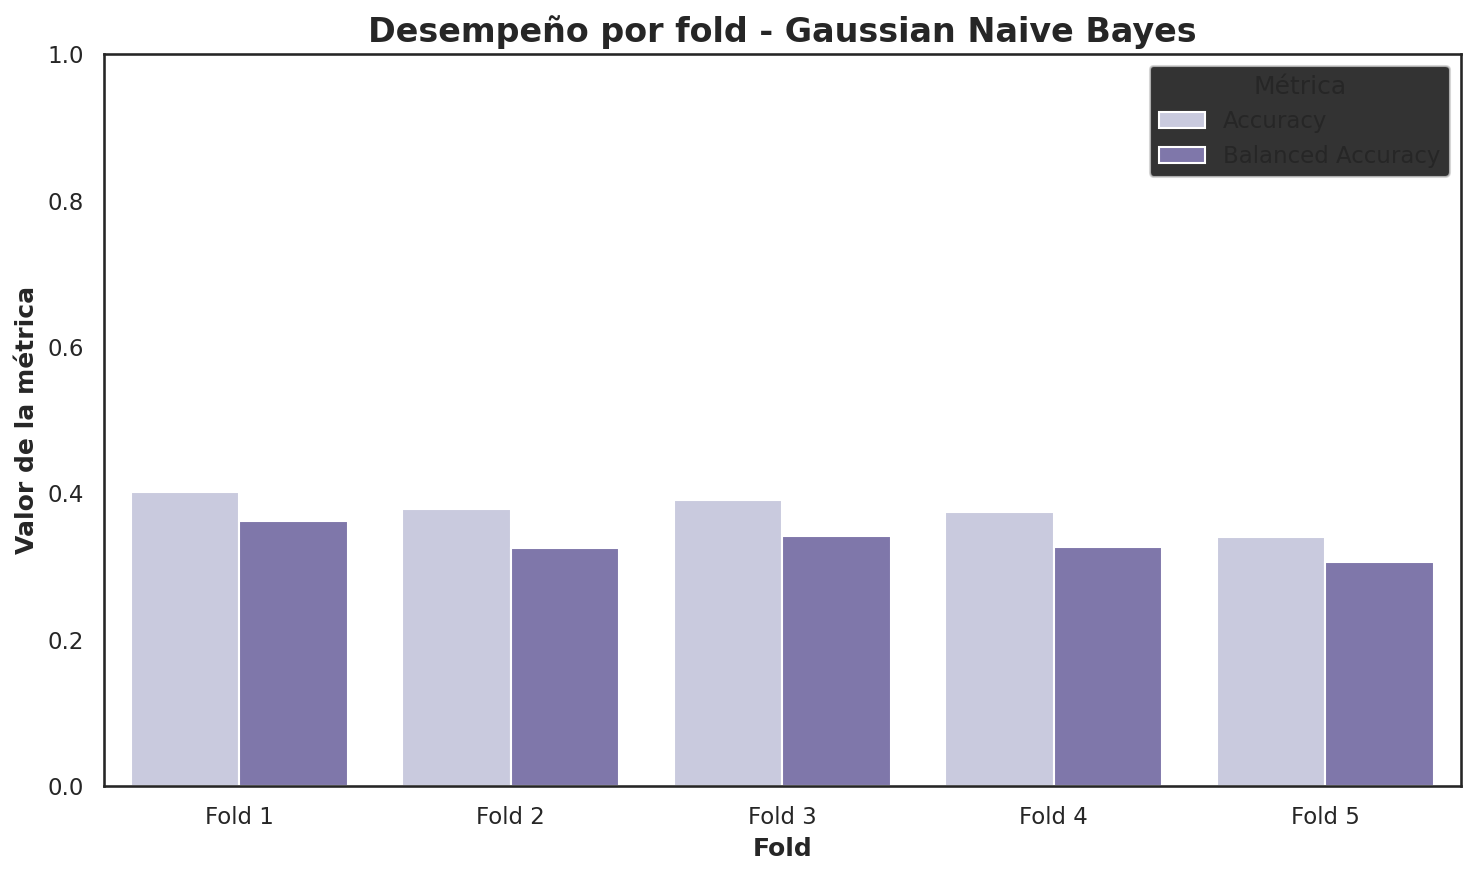

In [48]:
  df_scores = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, 6)],
    "Accuracy": acc_scores,
    "Balanced Accuracy": bacc_scores
})

plt.figure(figsize=(10, 6))
df_scores_plot = df_scores.melt(id_vars="Fold", var_name="Métrica", value_name="Valor")

sns.barplot(data=df_scores_plot, x="Fold", y="Valor", hue="Métrica", palette="Purples")

plt.title("Desempeño por fold - Gaussian Naive Bayes", fontsize=16, fontweight="bold")
plt.xlabel("Fold", fontsize=12, fontweight="bold")
plt.ylabel("Valor de la métrica", fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [49]:
print("Classification Report - Gaussian Naive Bayes")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - Gaussian Naive Bayes
              precision    recall  f1-score   support

  Blackheads       0.40      0.30      0.34       703
        Cyst       0.39      0.66      0.49       631
     Papules       0.34      0.33      0.33       611
    Pustules       0.36      0.27      0.31       576
  Whiteheads       0.57      0.10      0.17       118

    accuracy                           0.38      2639
   macro avg       0.41      0.33      0.33      2639
weighted avg       0.38      0.38      0.36      2639



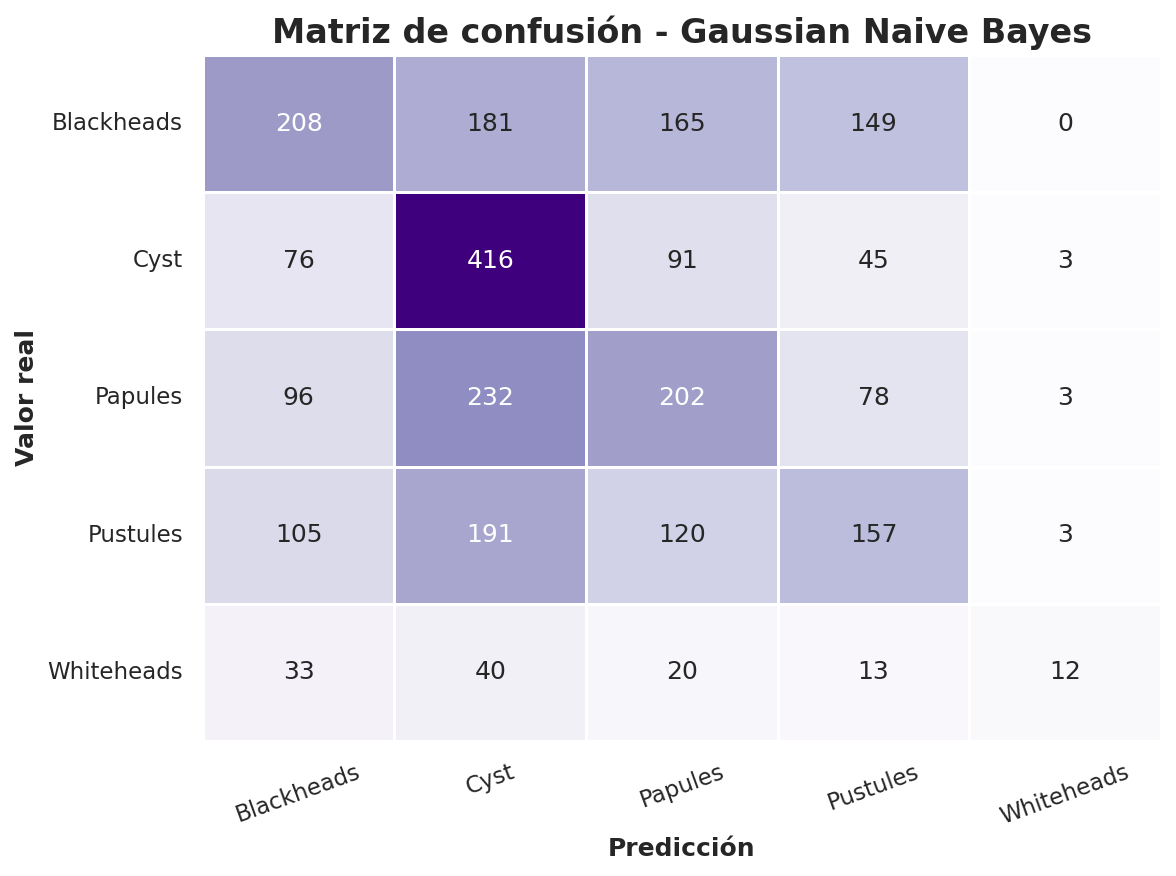

In [ ]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - Gaussian Naive Bayes", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12, fontweight="bold")
plt.ylabel("Valor real", fontsize=12, fontweight="bold")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

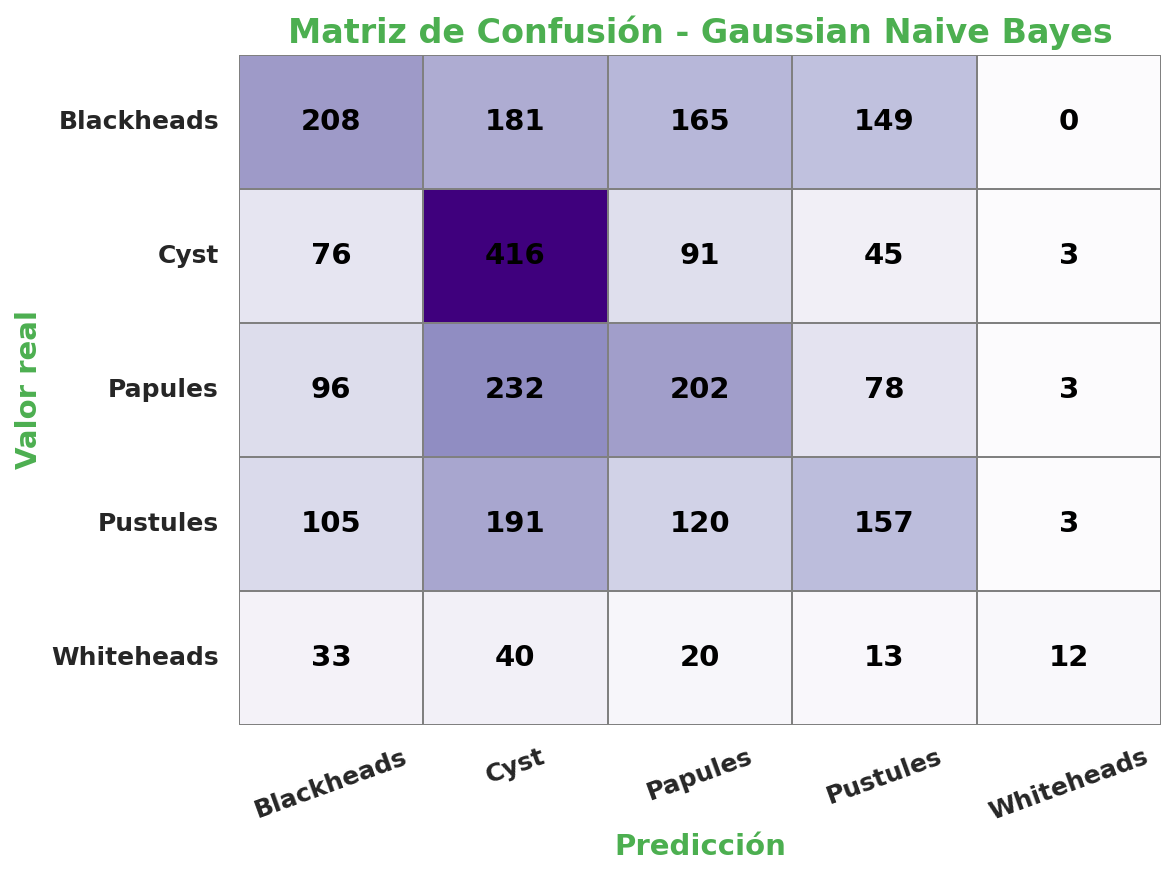

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

# Crear figura
plt.figure(figsize=(8, 6))

# Crear el heatmap con el color ajustado y bordes definidos
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Purples", cbar=False, linewidths=0.8, linecolor='gray', annot_kws={'size': 14, 'weight': 'bold', 'color': 'black'})

# Mejorar la presentación con título y etiquetas
plt.title("Matriz de Confusión - Gaussian Naive Bayes", fontsize=16, fontweight="bold", color='#4CAF50')
plt.xlabel("Predicción", fontsize=14, fontweight="bold", color='#4CAF50')
plt.ylabel("Valor real", fontsize=14, fontweight="bold", color='#4CAF50')

# Ajustar la rotación de los ejes
plt.xticks(rotation=20, fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')

# Ajustar la visualización
plt.tight_layout()

# Mostrar la matriz
plt.show()

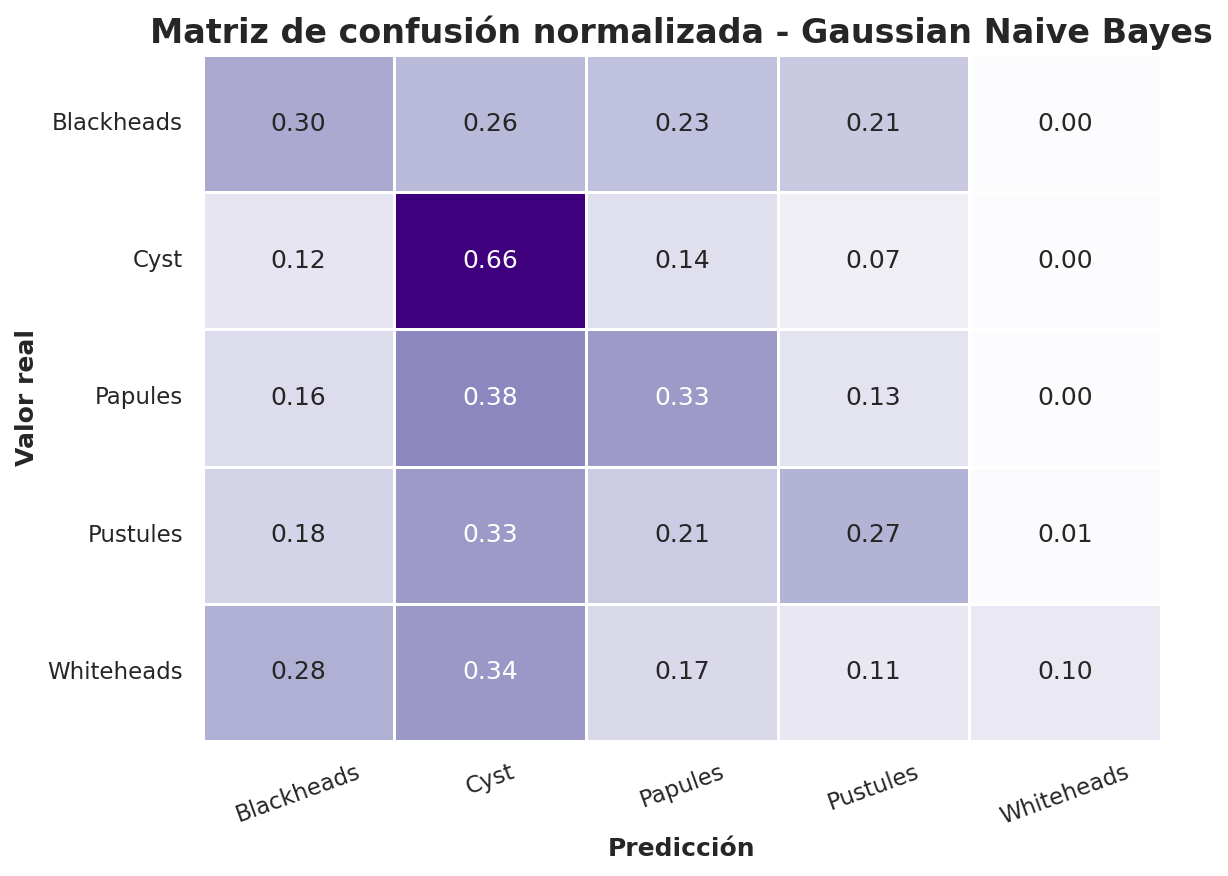

In [ ]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - Gaussian Naive Bayes", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12, fontweight="bold")
plt.ylabel("Valor real", fontsize=12, fontweight="bold")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

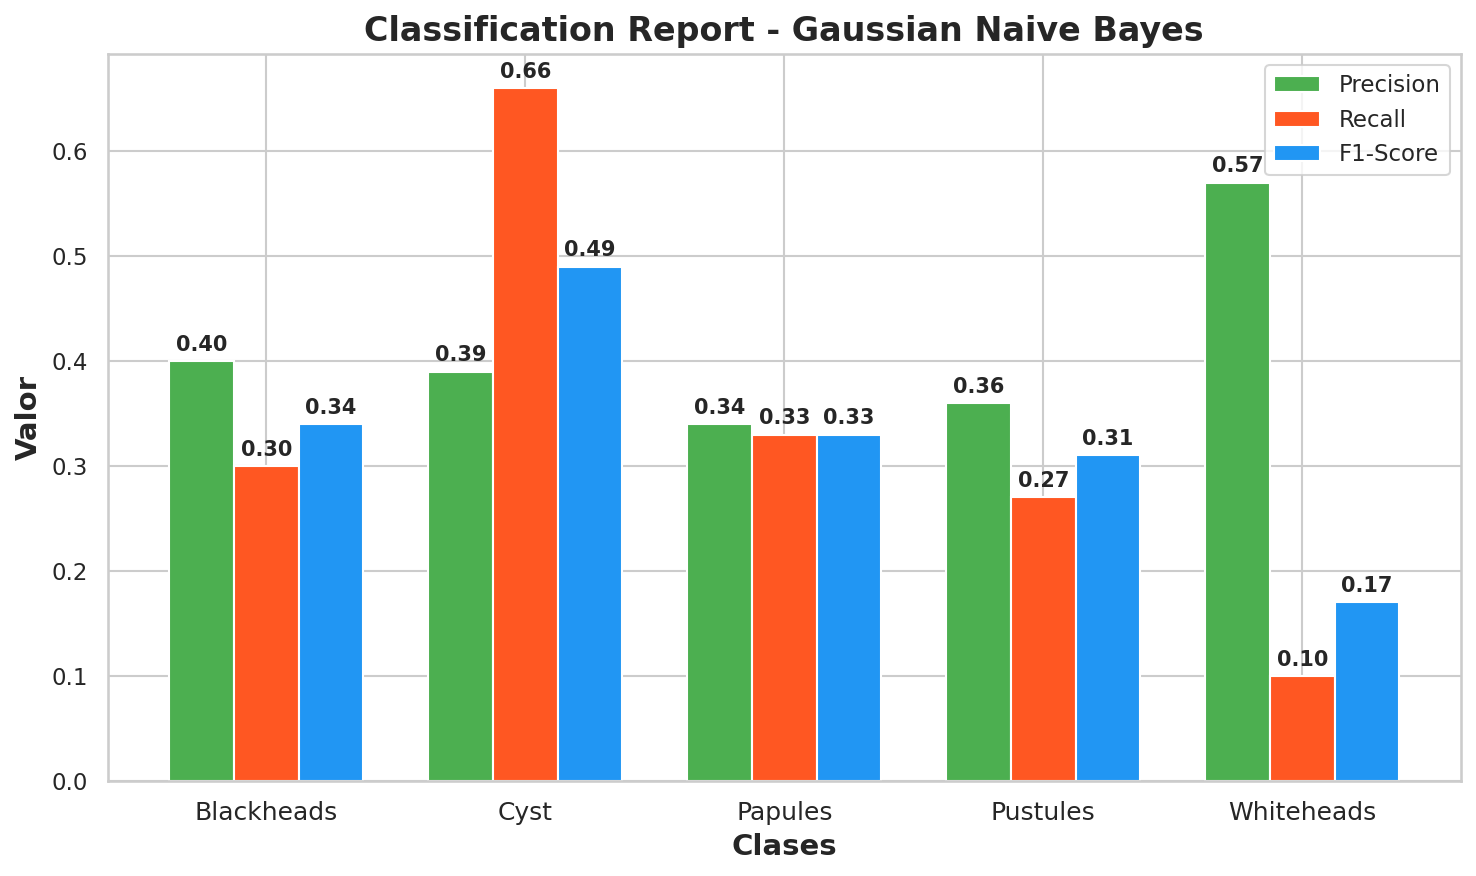

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del classification report
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.40, 0.39, 0.34, 0.36, 0.57]
recall = [0.30, 0.66, 0.33, 0.27, 0.10]
f1_score = [0.34, 0.49, 0.33, 0.31, 0.17]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - Gaussian Naive Bayes', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

Decision Three:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd

# Esquema de validación
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base
dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# Grid SOLO con profundidad del árbol
param_grid = {
    #"max_depth": [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
    "max_depth" : [1, 10, 20, 40, 50, 60, 80, 100, None]
}

# Grid Search
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_dt.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [1, 10, 20, 40, 50, 60, 80, 100, None]},
             return_train_score=True, scoring='balanced_accuracy')

In [ ]:
print("Mejor profundidad encontrada:", grid_dt.best_params_)
print("Mejor balanced accuracy:", round(grid_dt.best_score_, 4))

Mejor profundidad encontrada: {'max_depth': 40}
Mejor balanced accuracy: 0.659


In [ ]:
results_dt = pd.DataFrame(grid_dt.cv_results_)

results_dt[[
    "param_max_depth",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "rank_test_score"
]].sort_values("mean_test_score", ascending=False)

,param_max_depth,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
4,50,0.659011,0.016008,1.000000,0.000000,1
7,100,0.659011,0.016008,1.000000,0.000000,1
3,40,0.659011,0.016008,1.000000,0.000000,1
6,80,0.659011,0.016008,1.000000,0.000000,1
5,60,0.659011,0.016008,1.000000,0.000000,1
8,None,0.659011,0.016008,1.000000,0.000000,1
2,20,0.652269,0.025287,0.984069,0.014129,7
1,10,0.545186,0.006520,0.711684,0.016083,8
0,1,0.274679,0.013842,0.286588,0.006957,9


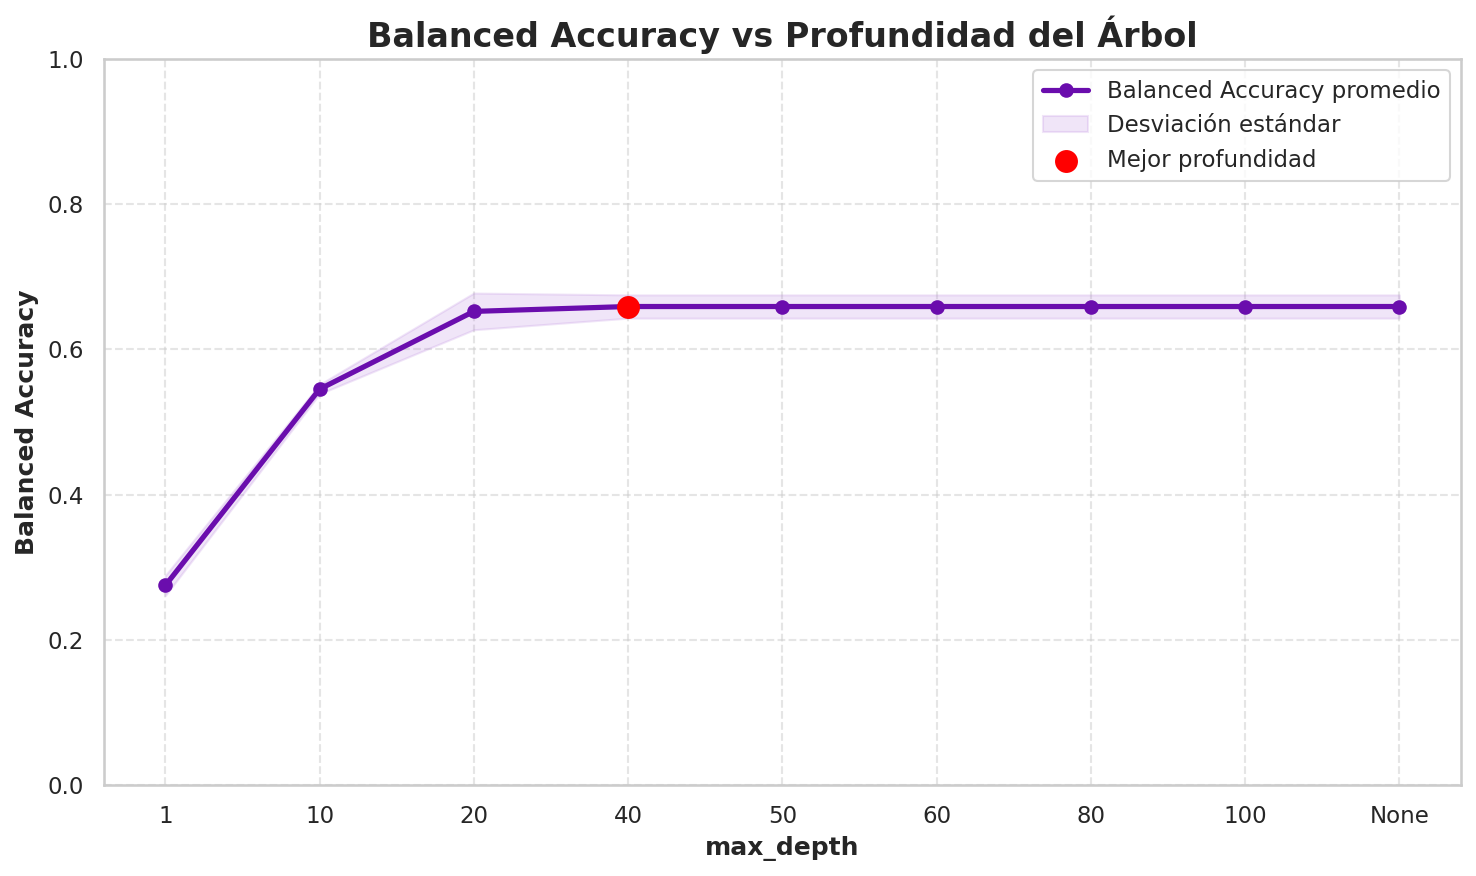

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

df_plot = results_dt.copy()
df_plot["param_max_depth"] = df_plot["param_max_depth"].astype(str)

# Orden de profundidades
#orden_depth = ["1", "2", "3", "4", "5", "6", "8", "10", "12", "15", "20", "None"]
orden_depth = ["1", "10", "20", "40", "50", "60", "80", "100", "None"]
df_plot["param_max_depth"] = pd.Categorical(
    df_plot["param_max_depth"],
    categories=orden_depth,
    ordered=True
)
df_plot = df_plot.sort_values("param_max_depth")

plt.figure(figsize=(10, 6))

# Balanced accuracy promedio en validación
plt.plot(
    df_plot["param_max_depth"],
    df_plot["mean_test_score"],
    marker="o",
    linewidth=2.5,
    color="#6A0DAD",
    label="Balanced Accuracy promedio"
)

# Banda de desviación estándar
plt.fill_between(
    range(len(df_plot)),
    df_plot["mean_test_score"] - df_plot["std_test_score"],
    df_plot["mean_test_score"] + df_plot["std_test_score"],
    alpha=0.2,
    color="#B57EDC",
    label="Desviación estándar"
)

# Resaltar mejor punto
best_idx = df_plot["mean_test_score"].idxmax()
best_x = list(df_plot.index).index(best_idx)
best_y = df_plot.loc[best_idx, "mean_test_score"]

plt.scatter(best_x, best_y, color="red", s=100, zorder=5, label="Mejor profundidad")

plt.title("Balanced Accuracy vs Profundidad del Árbol", fontsize=16, fontweight="bold")
plt.xlabel("max_depth", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

best_depth = grid_dt.best_params_["max_depth"]

best_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_dt.fit(X_train, y_train)
    y_pred = best_dt.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

print("Resultados globales - Decision Tree")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - Decision Tree
Accuracy promedio: 0.6635
Desviación estándar Accuracy: 0.0110
Balanced Accuracy promedio: 0.6590
Desviación estándar Balanced Accuracy: 0.0160


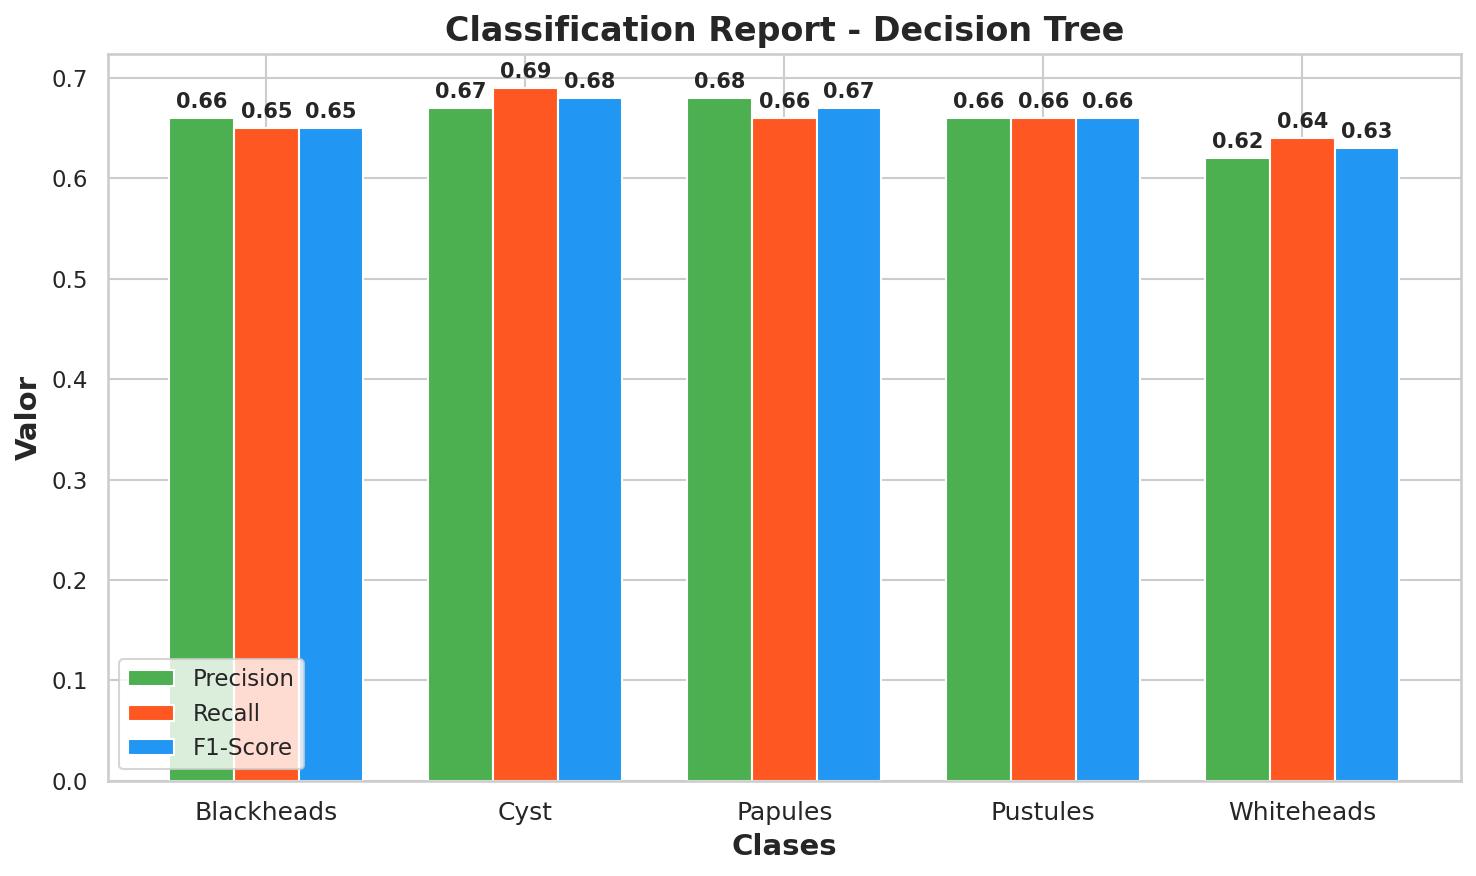

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del classification report - Decision Tree
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.66, 0.67, 0.68, 0.66, 0.62]
recall = [0.65, 0.69, 0.66, 0.66, 0.64]
f1_score = [0.65, 0.68, 0.67, 0.66, 0.63]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - Decision Tree', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

In [ ]:
print("Classification Report - Decision Tree")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - Decision Tree
              precision    recall  f1-score   support

  Blackheads       0.66      0.65      0.65       703
        Cyst       0.67      0.69      0.68       631
     Papules       0.68      0.66      0.67       611
    Pustules       0.66      0.66      0.66       576
  Whiteheads       0.62      0.64      0.63       118

    accuracy                           0.66      2639
   macro avg       0.66      0.66      0.66      2639
weighted avg       0.66      0.66      0.66      2639



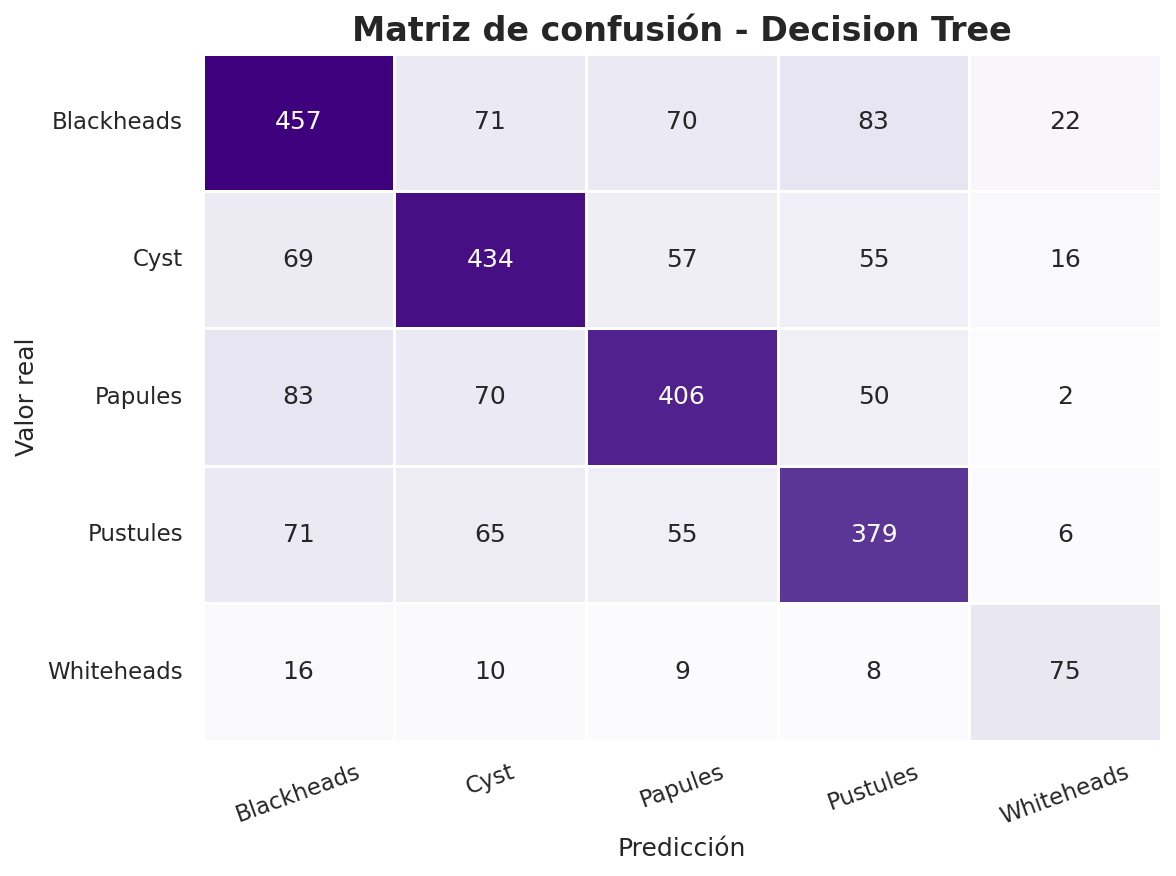

In [ ]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - Decision Tree", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

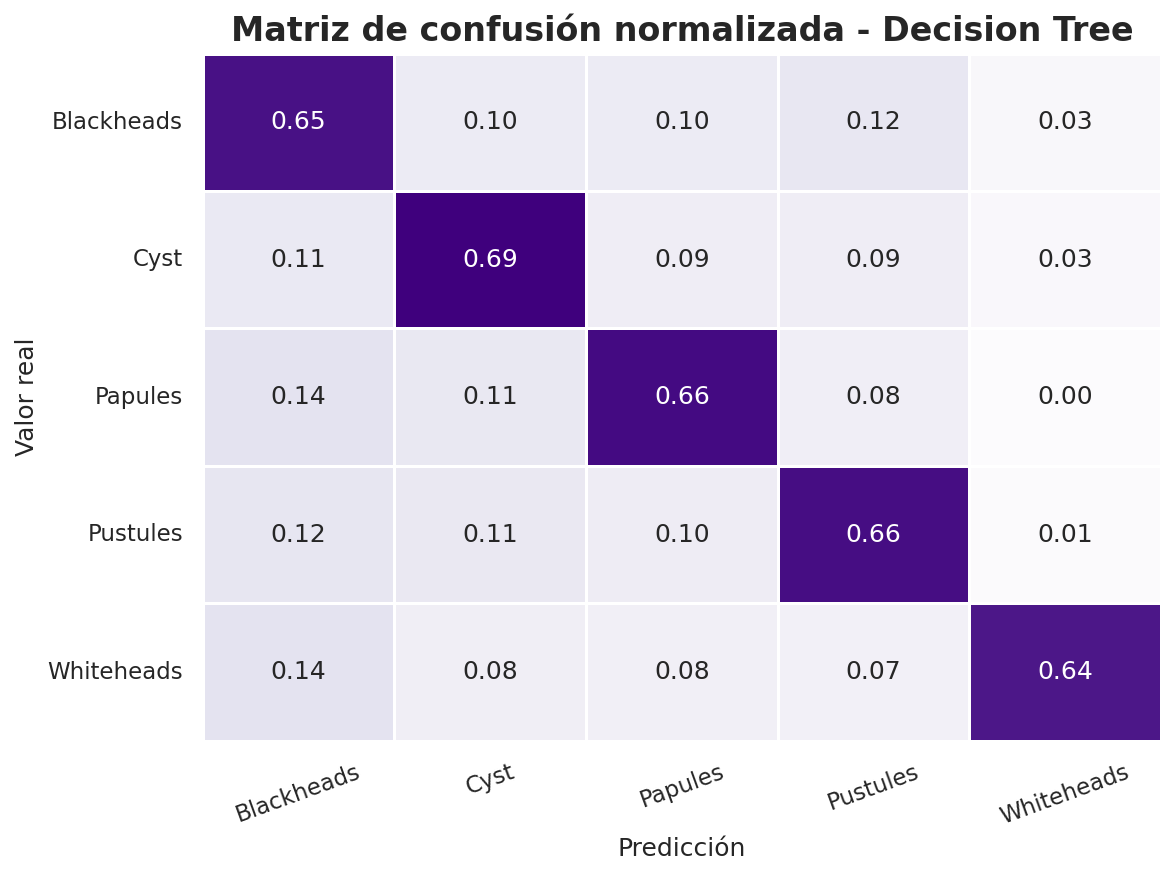

In [ ]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Purples", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - Decision Tree", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Random Forest:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd

# Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base con profundidad fija
rf = RandomForestClassifier(
    max_depth=40,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Grid solo para número de árboles
param_grid = {
    "n_estimators": [10, 20, 50, 100, 150, 200, 300]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_depth=40, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'n_estimators': [10, 20, 50, 100, 150, 200, 300]},
             return_train_score=True, scoring='balanced_accuracy')

In [ ]:
print("Mejor número de árboles encontrado:", grid_rf.best_params_)
print("Mejor balanced accuracy:", round(grid_rf.best_score_, 4))

Mejor número de árboles encontrado: {'n_estimators': 200}
Mejor balanced accuracy: 0.7365


In [ ]:
results_rf = pd.DataFrame(grid_rf.cv_results_)

results_rf[[
    "param_n_estimators",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "rank_test_score"
]].sort_values("mean_test_score", ascending=False)

,param_n_estimators,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
5,200,0.736488,0.022204,1.000000,0.000000,1
3,100,0.733769,0.026085,1.000000,0.000000,2
6,300,0.732131,0.024204,1.000000,0.000000,3
2,50,0.730692,0.029425,1.000000,0.000000,4
4,150,0.729767,0.029660,1.000000,0.000000,5
1,20,0.720070,0.022923,0.998661,0.001668,6
0,10,0.684767,0.027686,0.989775,0.002218,7


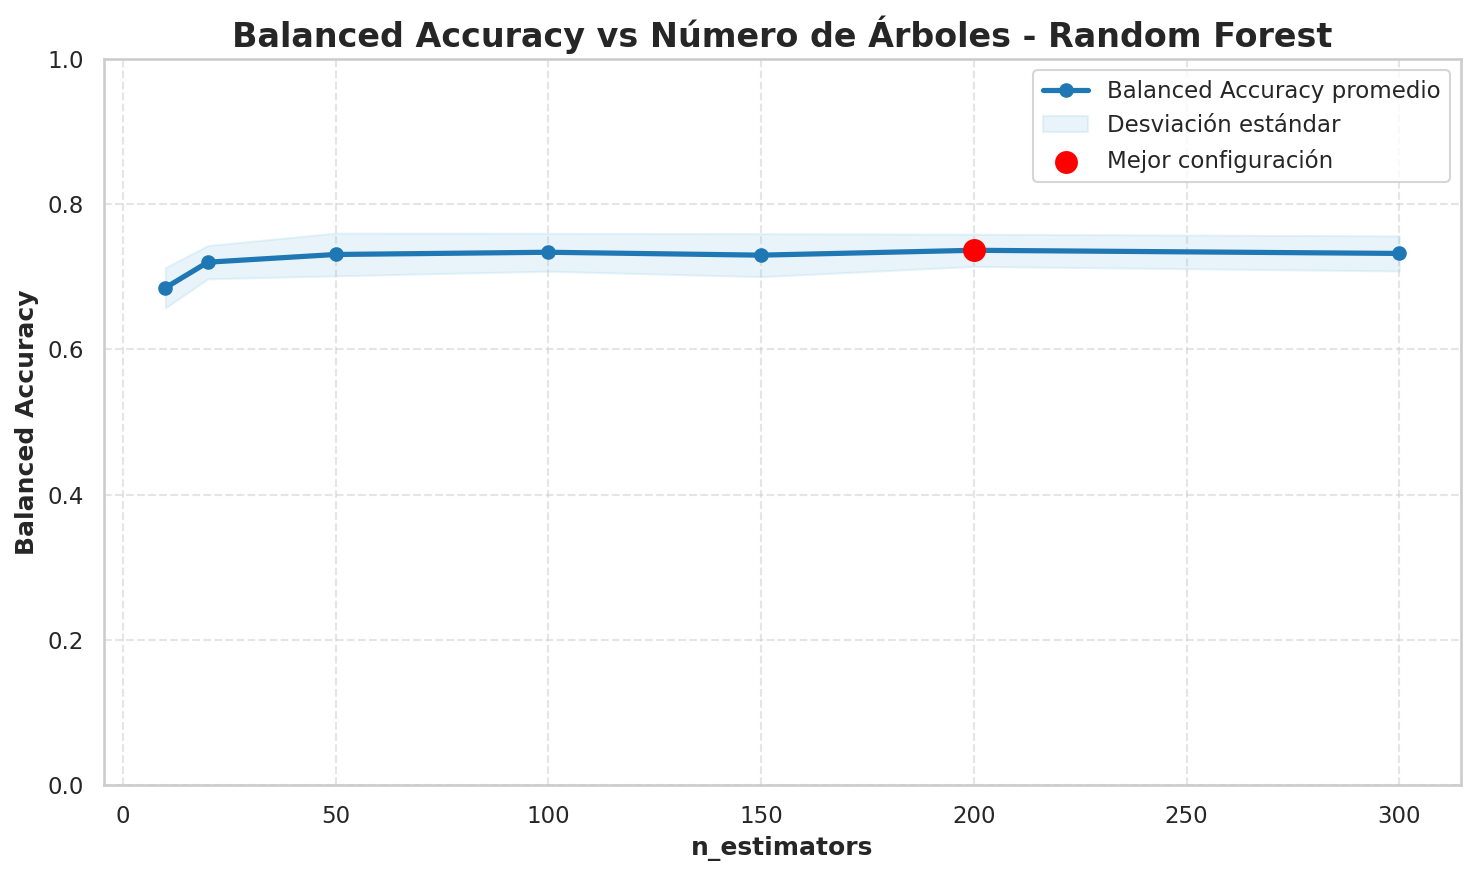

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

df_plot = results_rf.copy()
df_plot = df_plot.sort_values("param_n_estimators")

plt.figure(figsize=(10, 6))

plt.plot(
    df_plot["param_n_estimators"],
    df_plot["mean_test_score"],
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    label="Balanced Accuracy promedio"
)

plt.fill_between(
    df_plot["param_n_estimators"],
    df_plot["mean_test_score"] - df_plot["std_test_score"],
    df_plot["mean_test_score"] + df_plot["std_test_score"],
    alpha=0.2,
    color="#8ecae6",
    label="Desviación estándar"
)

# Resaltar mejor punto
best_idx = df_plot["mean_test_score"].idxmax()
best_x = df_plot.loc[best_idx, "param_n_estimators"]
best_y = df_plot.loc[best_idx, "mean_test_score"]

plt.scatter(best_x, best_y, color="red", s=100, zorder=5, label="Mejor configuración")

plt.title("Balanced Accuracy vs Número de Árboles - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("n_estimators", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

best_n = grid_rf.best_params_["n_estimators"]

best_rf = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=40,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

In [ ]:
print("Resultados globales - Random Forest")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - Random Forest
Accuracy promedio: 0.7567
Desviación estándar Accuracy: 0.0168
Balanced Accuracy promedio: 0.7365
Desviación estándar Balanced Accuracy: 0.0222


In [ ]:
print("Classification Report - Random Forest")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - Random Forest
              precision    recall  f1-score   support

  Blackheads       0.73      0.76      0.74       703
        Cyst       0.75      0.78      0.77       631
     Papules       0.75      0.79      0.77       611
    Pustules       0.78      0.72      0.75       576
  Whiteheads       0.94      0.64      0.76       118

    accuracy                           0.76      2639
   macro avg       0.79      0.74      0.76      2639
weighted avg       0.76      0.76      0.76      2639



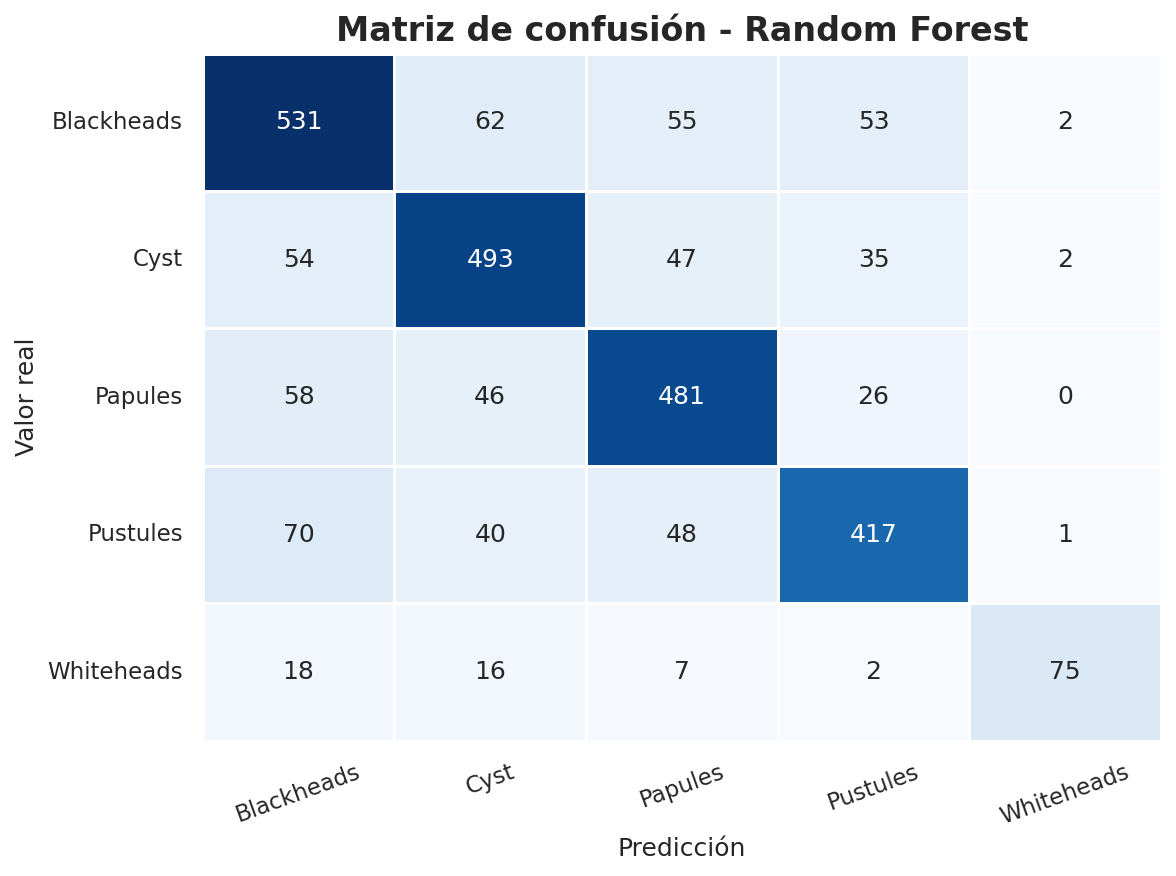

In [ ]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

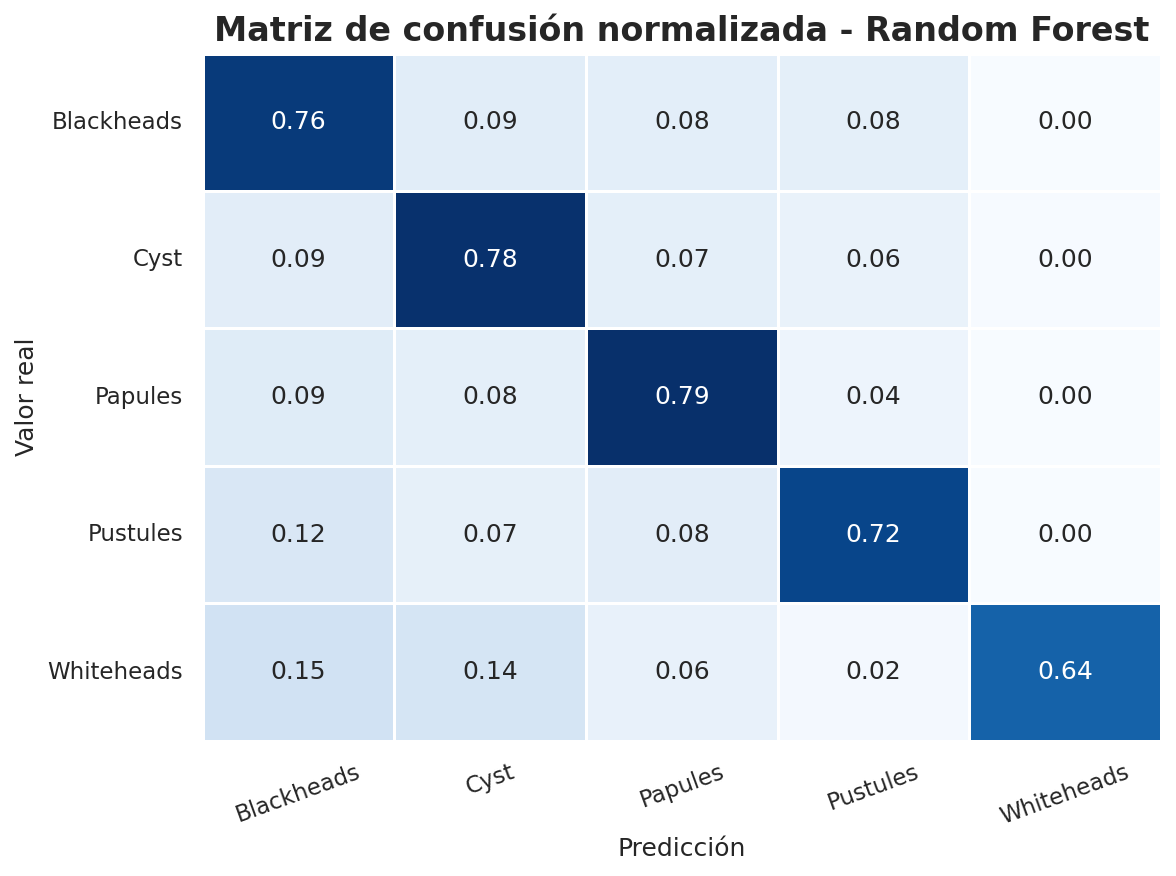

In [ ]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd

# Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Grid general
param_grid = {
    "n_estimators": [10, 15, 20, 50, 100],
    "max_depth": [1, 2, 5, 10, 15, 20]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2, 5, 10, 15, 20],
                         'n_estimators': [10, 15, 20, 50, 100]},
             return_train_score=True, scoring='balanced_accuracy')

In [74]:
print("Mejores hiperparámetros encontrados:")
print(grid_rf.best_params_)

print("\nMejor balanced accuracy:")
print(f"{grid_rf.best_score_:.4f}")

Mejores hiperparámetros encontrados:
{'max_depth': 20, 'n_estimators': 100}

Mejor balanced accuracy:
0.7365


In [75]:
results_rf = pd.DataFrame(grid_rf.cv_results_)

results_rf[[
    "param_n_estimators",
    "param_max_depth",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("mean_test_score", ascending=False).head(15)

,param_n_estimators,param_max_depth,mean_test_score,std_test_score,rank_test_score
29,100,20,0.736538,0.016027,1
24,100,15,0.734091,0.023718,2
28,50,20,0.727358,0.024952,3
23,50,15,0.721704,0.023032,4
27,20,20,0.721514,0.029945,5
22,20,15,0.717597,0.028107,6
26,15,20,0.705675,0.028653,7
21,15,15,0.700998,0.028910,8
19,100,10,0.694126,0.027813,9
25,10,20,0.691931,0.020541,10


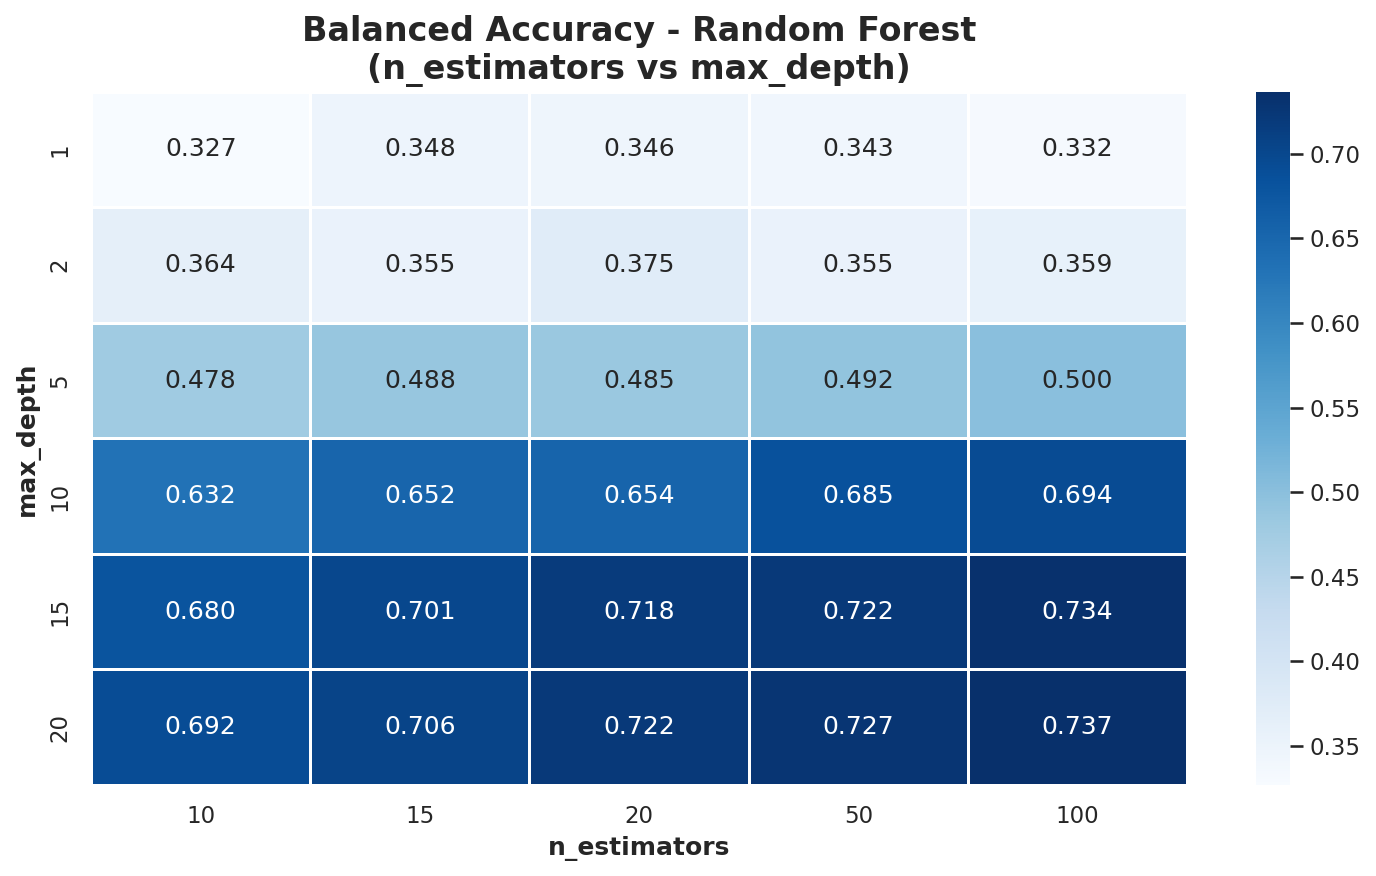

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

df_heat = results_rf.copy()
df_heat["param_max_depth"] = df_heat["param_max_depth"].astype(str)

pivot_rf = df_heat.pivot_table(
    index="param_max_depth",
    columns="param_n_estimators",
    values="mean_test_score"
)

orden_depth = ["1", "2", "5", "10", "15", "20"]
pivot_rf = pivot_rf.reindex(orden_depth)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_rf,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Balanced Accuracy - Random Forest\n(n_estimators vs max_depth)", fontsize=16, fontweight="bold")
plt.xlabel("n_estimators", fontsize=12, fontweight="bold")
plt.ylabel("max_depth", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

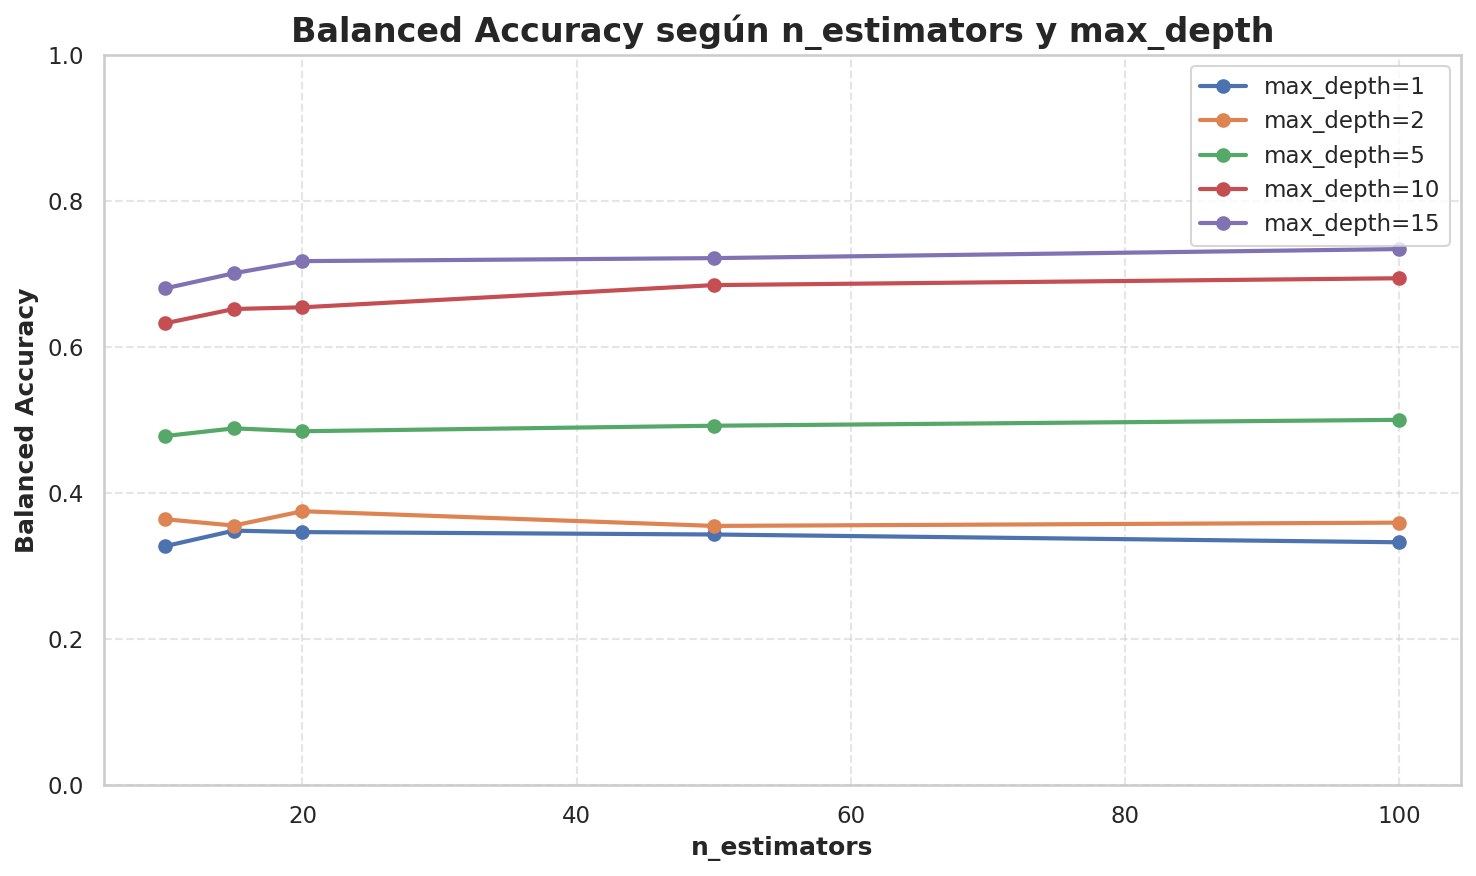

In [78]:
plt.figure(figsize=(10, 6))

df_lines = results_rf.copy()
df_lines["param_max_depth"] = df_lines["param_max_depth"].astype(str)

for depth in ["1", "2", "5", "10", "15"]:
    subset = df_lines[df_lines["param_max_depth"] == depth].sort_values("param_n_estimators")
    plt.plot(
        subset["param_n_estimators"],
        subset["mean_test_score"],
        marker="o",
        linewidth=2,
        label=f"max_depth={depth}"
    )

plt.title("Balanced Accuracy según n_estimators y max_depth", fontsize=16, fontweight="bold")
plt.xlabel("n_estimators", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np

best_rf = RandomForestClassifier(
    **grid_rf.best_params_,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [ ]:
acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

In [ ]:
print("Resultados globales - Random Forest")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - Random Forest
Accuracy promedio: 0.7579
Desviación estándar Accuracy: 0.0152
Balanced Accuracy promedio: 0.7376
Desviación estándar Balanced Accuracy: 0.0188


In [ ]:
print("Classification Report - Random Forest")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - Random Forest
              precision    recall  f1-score   support

  Blackheads       0.73      0.75      0.74       703
        Cyst       0.75      0.78      0.77       631
     Papules       0.76      0.79      0.77       611
    Pustules       0.77      0.73      0.75       576
  Whiteheads       0.93      0.64      0.75       118

    accuracy                           0.76      2639
   macro avg       0.79      0.74      0.76      2639
weighted avg       0.76      0.76      0.76      2639



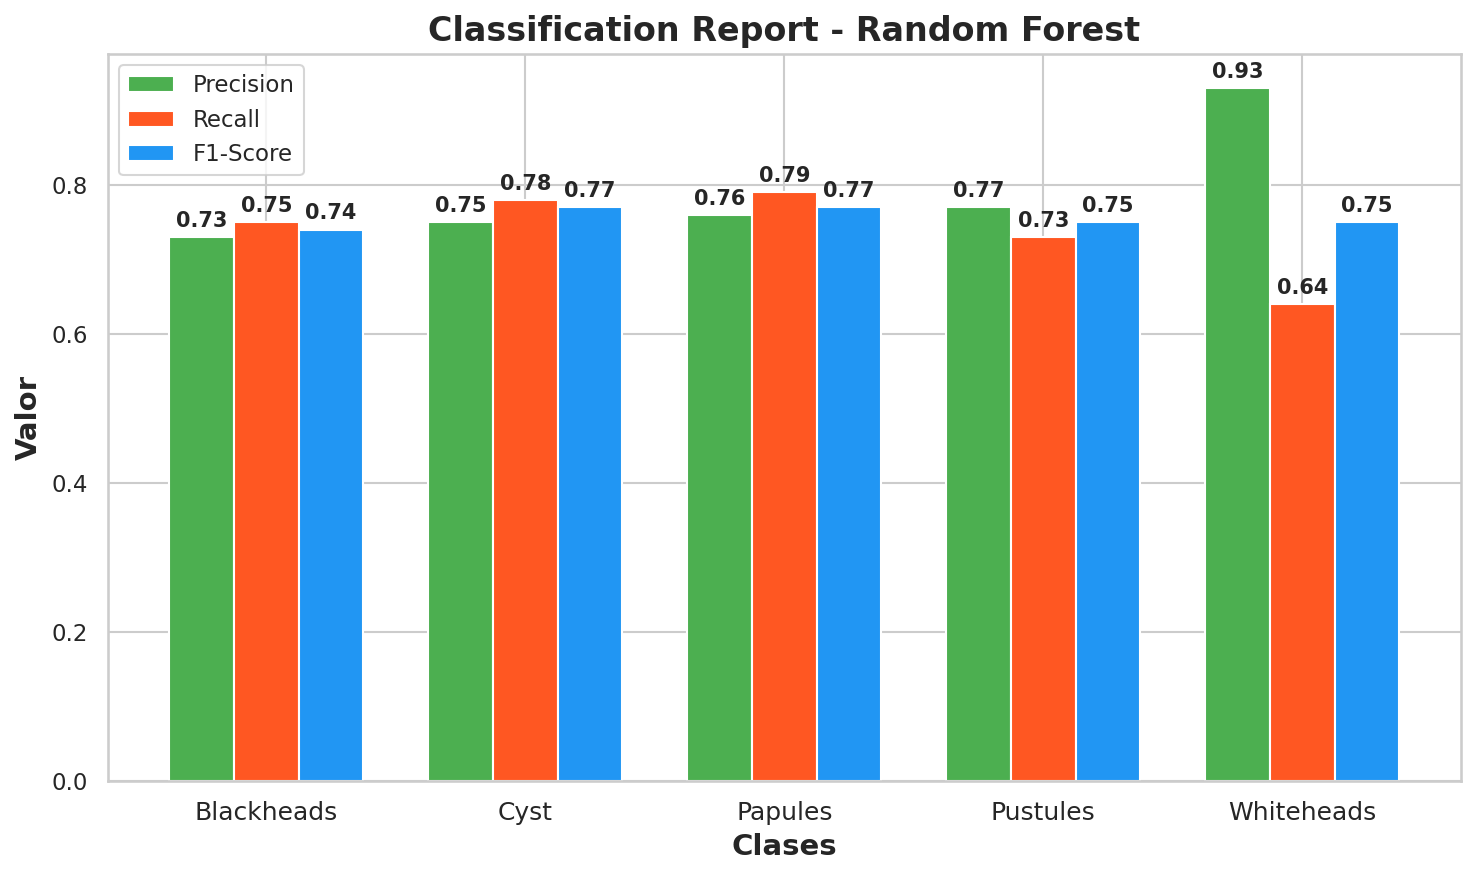

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del classification report - Random Forest
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.73, 0.75, 0.76, 0.77, 0.93]
recall = [0.75, 0.78, 0.79, 0.73, 0.64]
f1_score = [0.74, 0.77, 0.77, 0.75, 0.75]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - Random Forest', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

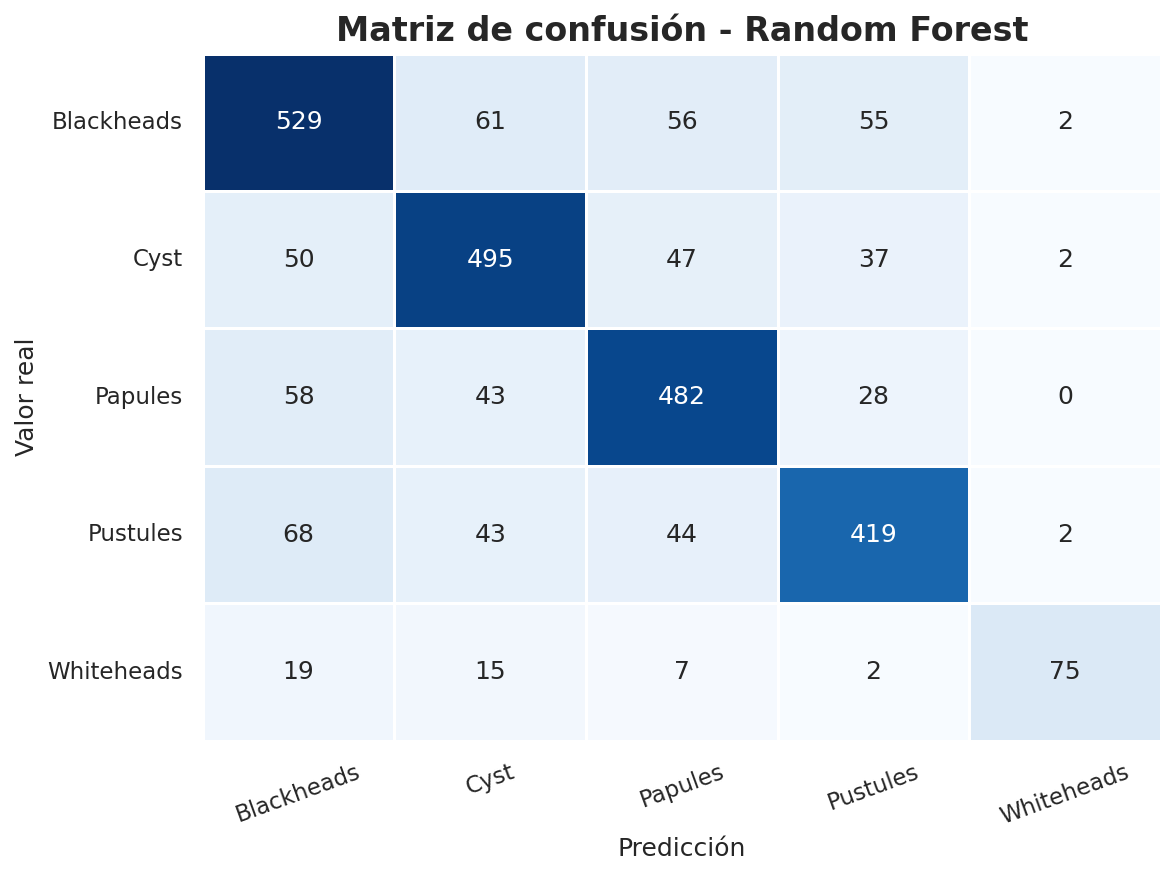

In [ ]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

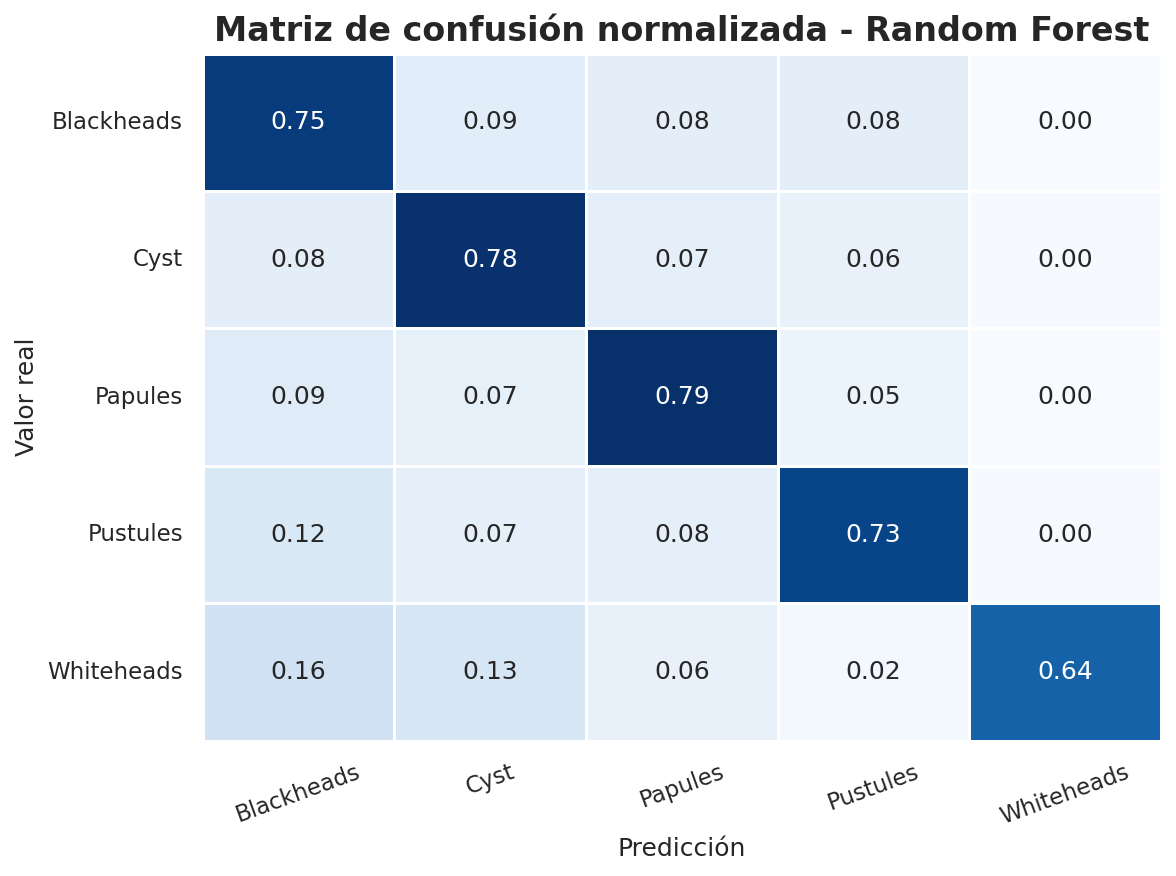

In [ ]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - Random Forest", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

SVM:

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np

# Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kernels = ["linear", "poly", "rbf", "sigmoid"]

resultados_kernel = []

for k in kernels:
    model = SVC(
        kernel=k,
        C=1.0,
        class_weight="balanced",
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    resultados_kernel.append({
        "Kernel": k,
        "Balanced_Accuracy_Mean": scores.mean(),
        "Balanced_Accuracy_Std": scores.std()
    })

df_kernels = pd.DataFrame(resultados_kernel)
df_kernels

,Kernel,Balanced_Accuracy_Mean,Balanced_Accuracy_Std
0,linear,0.328859,0.009214
1,poly,0.429116,0.022852
2,rbf,0.503324,0.015356
3,sigmoid,0.210272,0.012874


In [ ]:
best_row = df_kernels.loc[df_kernels["Balanced_Accuracy_Mean"].idxmax()]
best_kernel = best_row["Kernel"]

print("Mejor kernel encontrado:", best_kernel)
print("Balanced Accuracy promedio:", round(best_row["Balanced_Accuracy_Mean"], 4))
print("Desviación estándar:", round(best_row["Balanced_Accuracy_Std"], 4))

Mejor kernel encontrado: rbf
Balanced Accuracy promedio: 0.5033
Desviación estándar: 0.0154


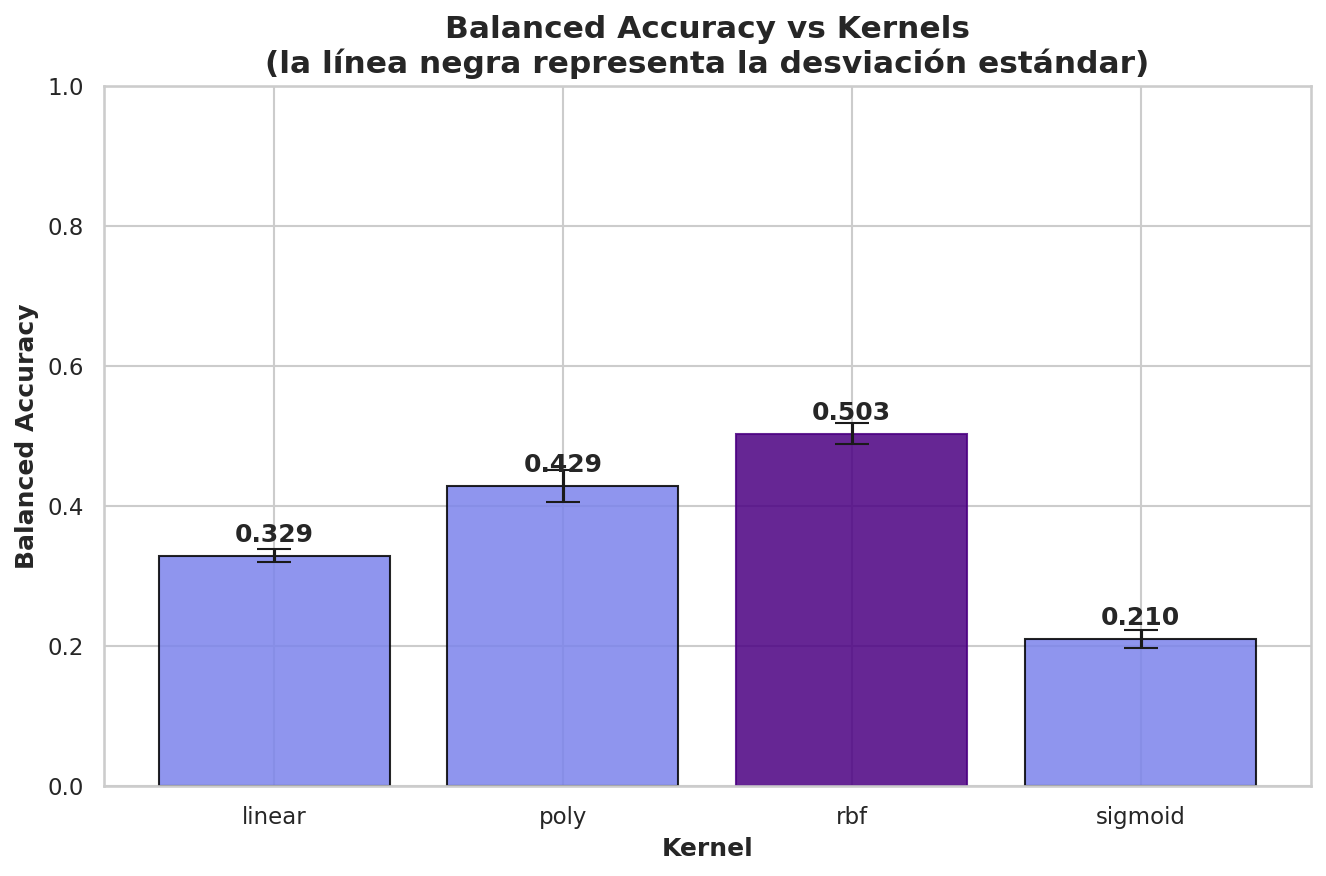

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

plt.figure(figsize=(9, 6))

bars = plt.bar(
    df_kernels["Kernel"],
    df_kernels["Balanced_Accuracy_Mean"],
    yerr=df_kernels["Balanced_Accuracy_Std"],
    capsize=8,
    color="#7B83EB",
    edgecolor="black",
    alpha=0.85
)

# Resaltar mejor kernel
best_index = df_kernels["Balanced_Accuracy_Mean"].idxmax()
bars[list(df_kernels.index).index(best_index)].set_color("#4B0082")

plt.title("Balanced Accuracy vs Kernels\n(la línea negra representa la desviación estándar)", fontsize=15, fontweight="bold")
plt.xlabel("Kernel", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)

# Etiquetas encima de las barras
for i, row in df_kernels.iterrows():
    plt.text(
        i,
        row["Balanced_Accuracy_Mean"] + 0.02,
        f"{row['Balanced_Accuracy_Mean']:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

best_svm = SVC(
    kernel=best_kernel,
    C=1.0,
    class_weight="balanced",
    random_state=42
)

acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_svm.fit(X_train, y_train)
    y_pred = best_svm.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

In [ ]:
print("Resultados globales - SVM")
print(f"Kernel seleccionado: {best_kernel}")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - SVM
Kernel seleccionado: rbf
Accuracy promedio: 0.4513
Desviación estándar Accuracy: 0.0216
Balanced Accuracy promedio: 0.5033
Desviación estándar Balanced Accuracy: 0.0154


In [ ]:
print("Classification Report - SVM")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - SVM
              precision    recall  f1-score   support

  Blackheads       0.56      0.34      0.42       703
        Cyst       0.51      0.48      0.50       631
     Papules       0.46      0.50      0.48       611
    Pustules       0.48      0.44      0.46       576
  Whiteheads       0.21      0.75      0.33       118

    accuracy                           0.45      2639
   macro avg       0.44      0.50      0.44      2639
weighted avg       0.49      0.45      0.46      2639



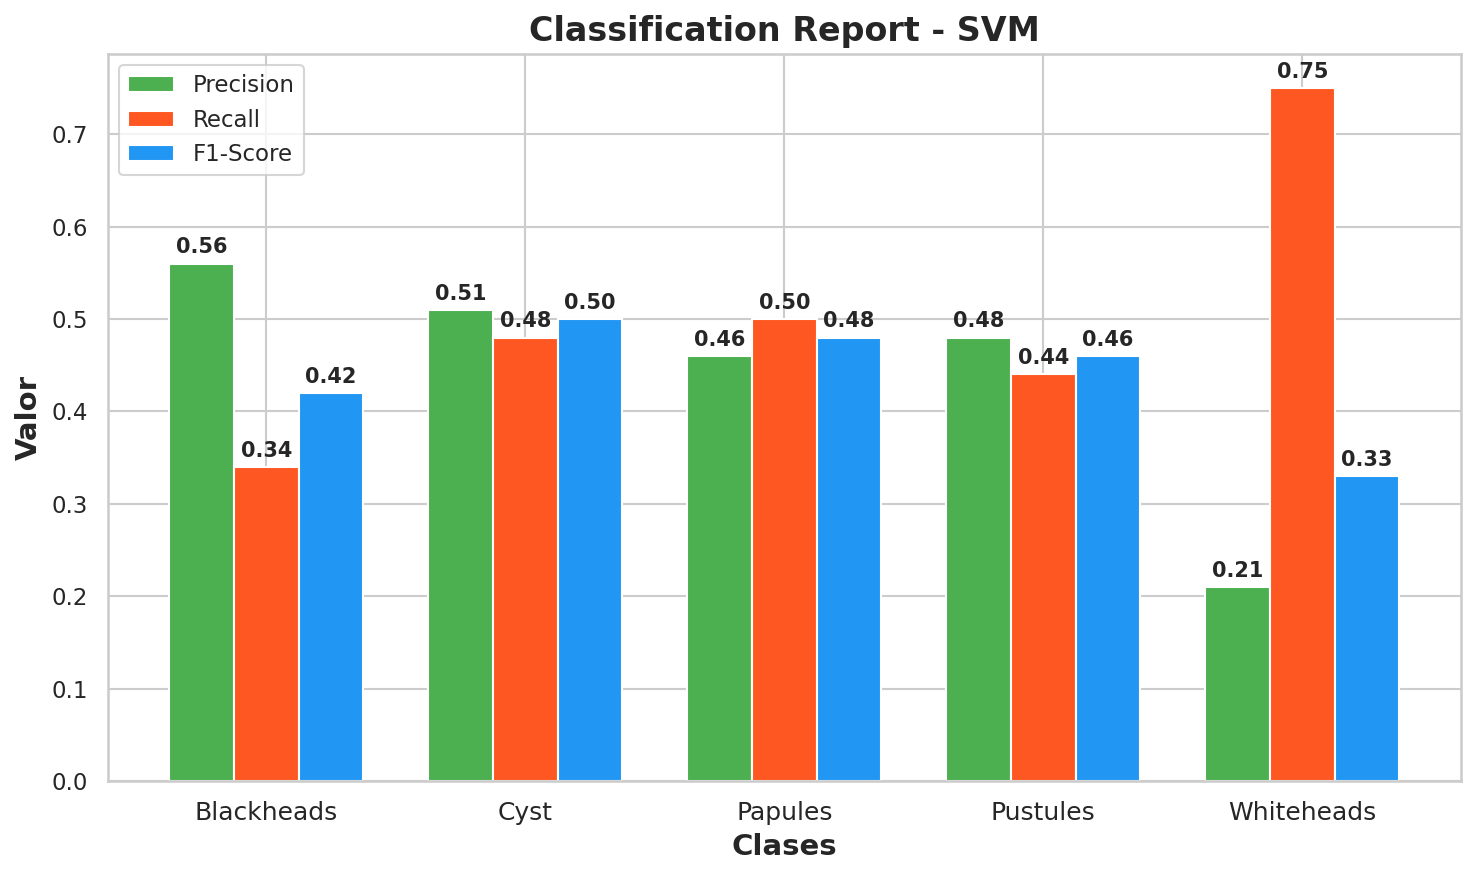

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del classification report - SVM
clases = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
precision = [0.56, 0.51, 0.46, 0.48, 0.21]
recall = [0.34, 0.48, 0.50, 0.44, 0.75]
f1_score = [0.42, 0.50, 0.48, 0.46, 0.33]

# Crear gráfico de barras
x = np.arange(len(clases))  # Las posiciones de las clases
width = 0.25  # El ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras para las tres métricas
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = ax.bar(x, recall, width, label='Recall', color='#FF5722')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2196F3')

# Añadir texto encima de las barras
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects3:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Desplazar el texto
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Personalización del gráfico
ax.set_xlabel('Clases', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=14, fontweight='bold')
ax.set_title('Classification Report - SVM', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=12)
ax.legend()

# Mostrar la gráfica
fig.tight_layout()
plt.show()

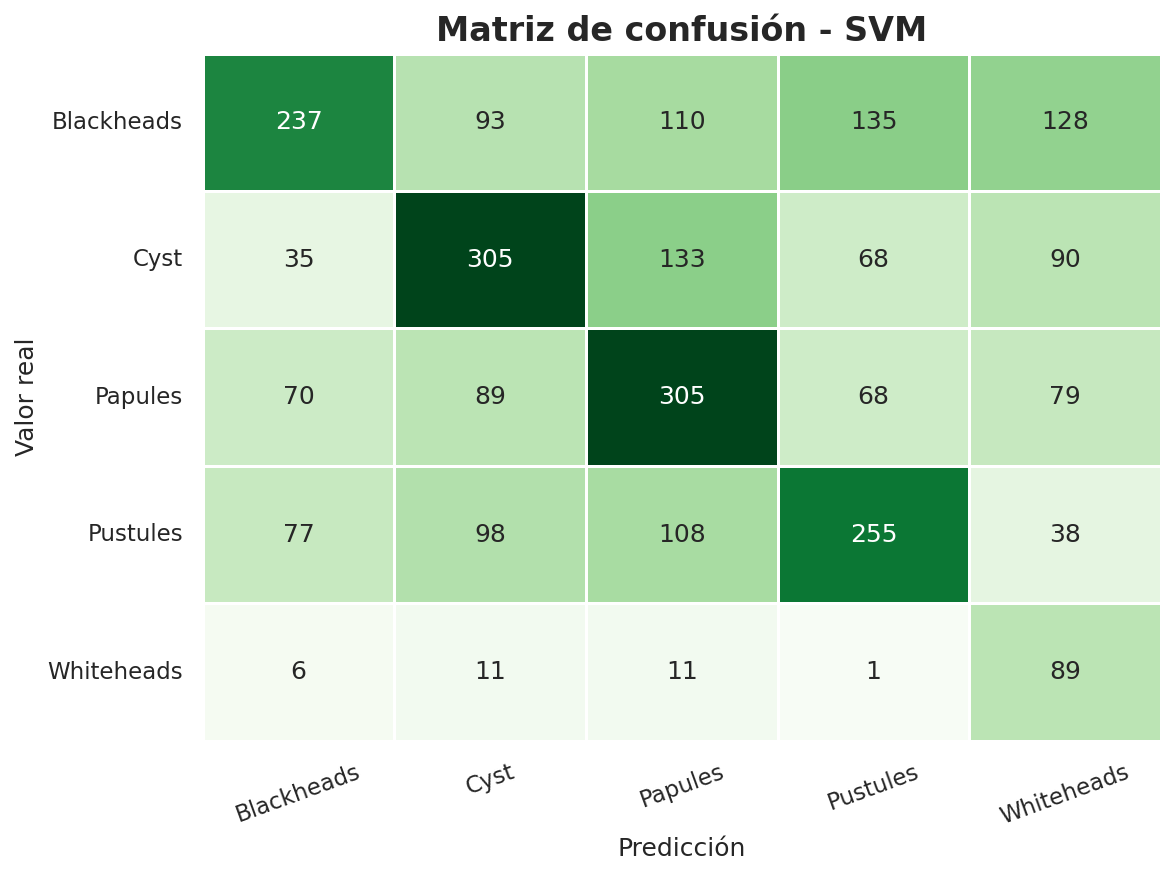

In [ ]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - SVM", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd

# Validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo base
svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

# Grid de hiperparámetros
param_grid = {
    "C": [0.01, 0.1, 1, 10, 50, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=skf,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_svm.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(class_weight='balanced', random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 50, 100],
                         'gamma': ['scale', 0.001, 0.01, 0.1, 1]},
             return_train_score=True, scoring='balanced_accuracy')

In [ ]:
print("Mejores hiperparámetros encontrados:")
print(grid_svm.best_params_)

print("\nMejor balanced accuracy:")
print(f"{grid_svm.best_score_:.4f}")

Mejores hiperparámetros encontrados:
{'C': 100, 'gamma': 1}

Mejor balanced accuracy:
0.6968


In [ ]:
results_svm = pd.DataFrame(grid_svm.cv_results_)

results_svm[[
    "param_C",
    "param_gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("mean_test_score", ascending=False).head(15)

,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
29,100.0,1,0.696804,0.028694,1
24,50.0,1,0.684980,0.023362,2
19,10.0,1,0.677104,0.016929,3
25,100.0,scale,0.603861,0.015095,4
14,1.0,1,0.580705,0.021030,5
20,50.0,scale,0.579701,0.024795,6
15,10.0,scale,0.554487,0.018670,7
28,100.0,0.1,0.548058,0.019313,8
23,50.0,0.1,0.531656,0.024387,9
18,10.0,0.1,0.507834,0.019854,10


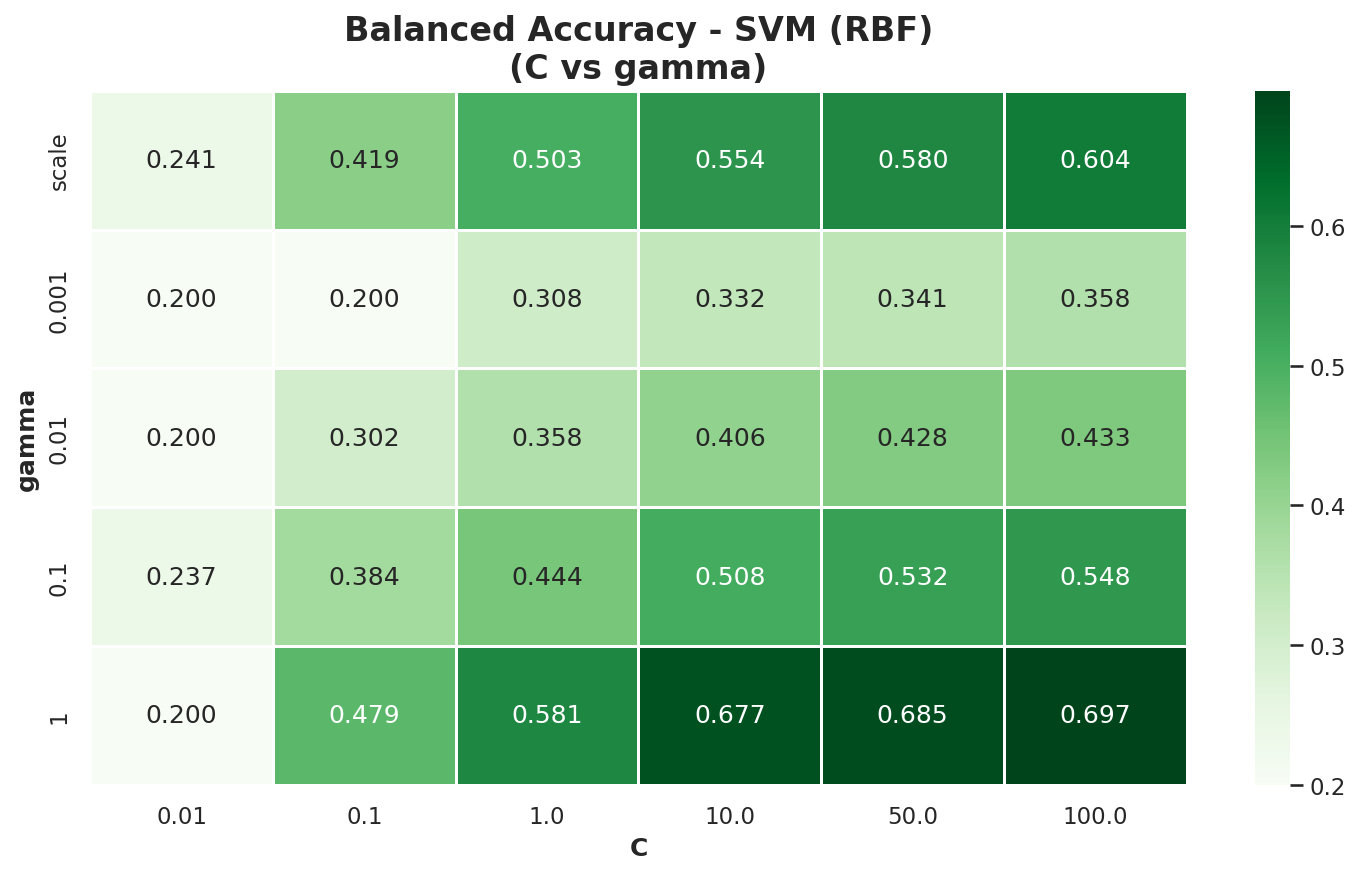

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

df_heat = results_svm.copy()
df_heat["param_gamma"] = df_heat["param_gamma"].astype(str)

pivot_svm = df_heat.pivot_table(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

# Ordenar gamma para que se vea mejor
orden_gamma = ["scale", "0.001", "0.01", "0.1", "1"]
pivot_svm = pivot_svm.reindex(orden_gamma)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_svm,
    annot=True,
    fmt=".3f",
    cmap="Greens",
    linewidths=0.5
)

plt.title("Balanced Accuracy - SVM (RBF)\n(C vs gamma)", fontsize=16, fontweight="bold")
plt.xlabel("C", fontsize=12, fontweight="bold")
plt.ylabel("gamma", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np

best_svm = SVC(
    kernel="rbf",
    C=grid_svm.best_params_["C"],
    gamma=grid_svm.best_params_["gamma"],
    class_weight="balanced",
    random_state=42
)

acc_scores = []
bacc_scores = []
y_true_total = []
y_pred_total = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_svm.fit(X_train, y_train)
    y_pred = best_svm.predict(X_test)

    acc_scores.append(accuracy_score(y_test, y_pred))
    bacc_scores.append(balanced_accuracy_score(y_test, y_pred))

    y_true_total.extend(y_test)
    y_pred_total.extend(y_pred)

In [ ]:
print("Resultados globales - SVM ajustado")
print(f"Accuracy promedio: {np.mean(acc_scores):.4f}")
print(f"Desviación estándar Accuracy: {np.std(acc_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(bacc_scores):.4f}")
print(f"Desviación estándar Balanced Accuracy: {np.std(bacc_scores):.4f}")

Resultados globales - SVM ajustado
Accuracy promedio: 0.7029
Desviación estándar Accuracy: 0.0206
Balanced Accuracy promedio: 0.6968
Desviación estándar Balanced Accuracy: 0.0287


In [ ]:
print("Classification Report - SVM ajustado")
print(classification_report(y_true_total, y_pred_total, target_names=le.classes_))

Classification Report - SVM ajustado
              precision    recall  f1-score   support

  Blackheads       0.68      0.72      0.70       703
        Cyst       0.71      0.72      0.72       631
     Papules       0.71      0.70      0.71       611
    Pustules       0.73      0.68      0.70       576
  Whiteheads       0.62      0.67      0.64       118

    accuracy                           0.70      2639
   macro avg       0.69      0.70      0.69      2639
weighted avg       0.70      0.70      0.70      2639



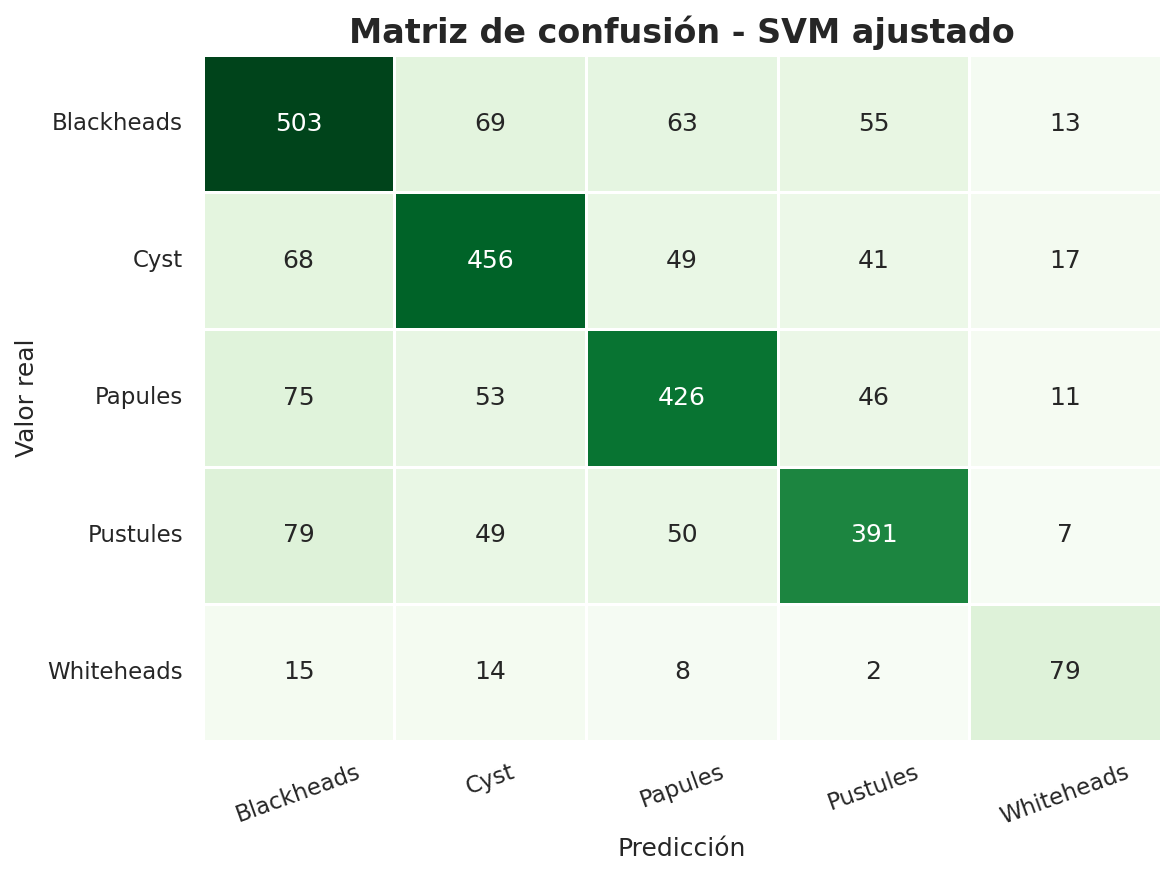

In [ ]:
cm = confusion_matrix(y_true_total, y_pred_total)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión - SVM ajustado", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

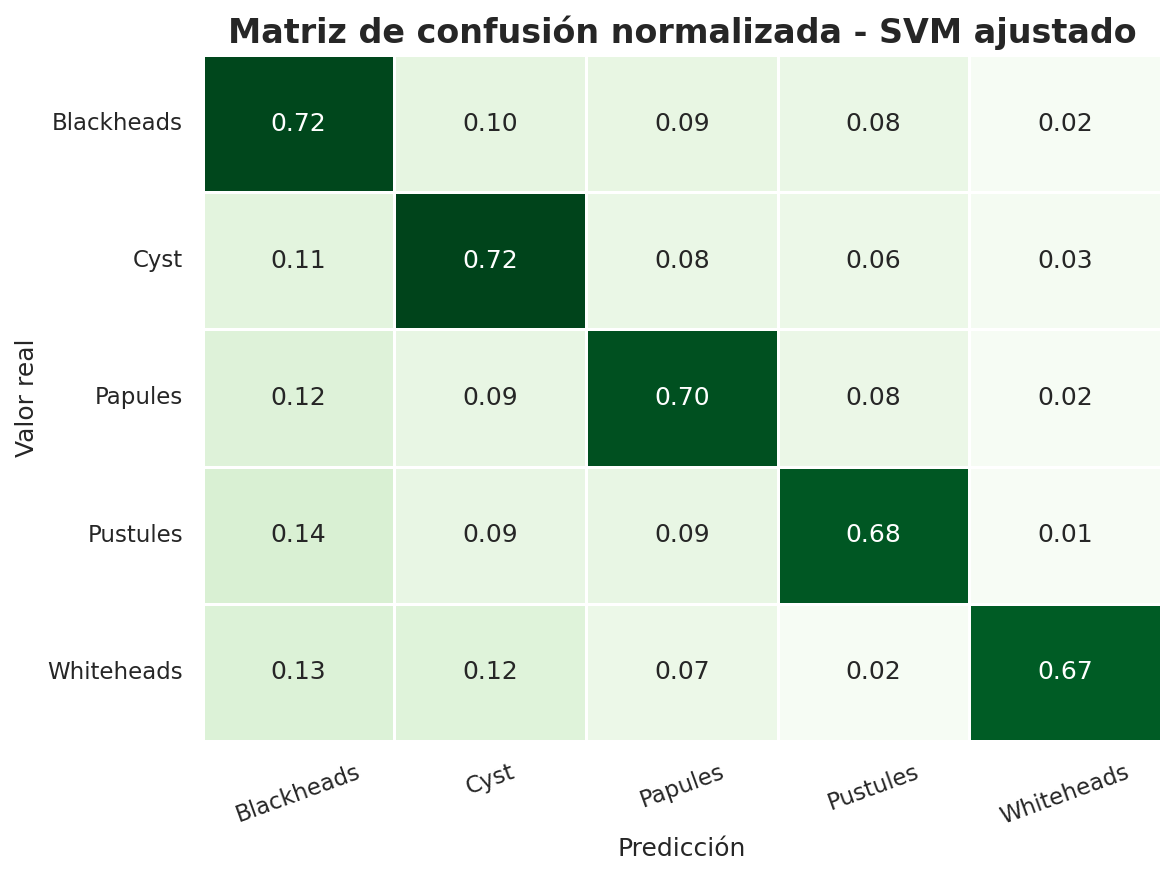

In [ ]:
cm_norm = confusion_matrix(y_true_total, y_pred_total, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Greens", cbar=False, linewidths=0.5)
plt.title("Matriz de confusión normalizada - SVM ajustado", fontsize=16, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df_modelos = pd.DataFrame({
    "Modelo": [
        "GaussianNB",
        "Decision Tree",
        "Random Forest",
        "SVM ajustado"
    ],
    "Accuracy": [0.377, 0.660, 0.758, 0.703],
    "Balanced Accuracy": [0.332, 0.659, 0.738, 0.697],
    "F1 Macro": [0.33, 0.66, 0.76, 0.69]
})

df_modelos

,Modelo,Accuracy,Balanced Accuracy,F1 Macro
0,GaussianNB,0.377,0.332,0.33
1,Decision Tree,0.660,0.659,0.66
2,Random Forest,0.758,0.738,0.76
3,SVM ajustado,0.703,0.697,0.69


In [ ]:
df_modelos_estilo = df_modelos.copy()

for col in ["Accuracy", "Balanced Accuracy", "F1 Macro"]:
    df_modelos_estilo[col] = (df_modelos_estilo[col] * 100).round(1).astype(str) + "%"

df_modelos_estilo

,Modelo,Accuracy,Balanced Accuracy,F1 Macro
0,GaussianNB,37.7%,33.2%,33.0%
1,Decision Tree,66.0%,65.9%,66.0%
2,Random Forest,75.8%,73.8%,76.0%
3,SVM ajustado,70.3%,69.7%,69.0%


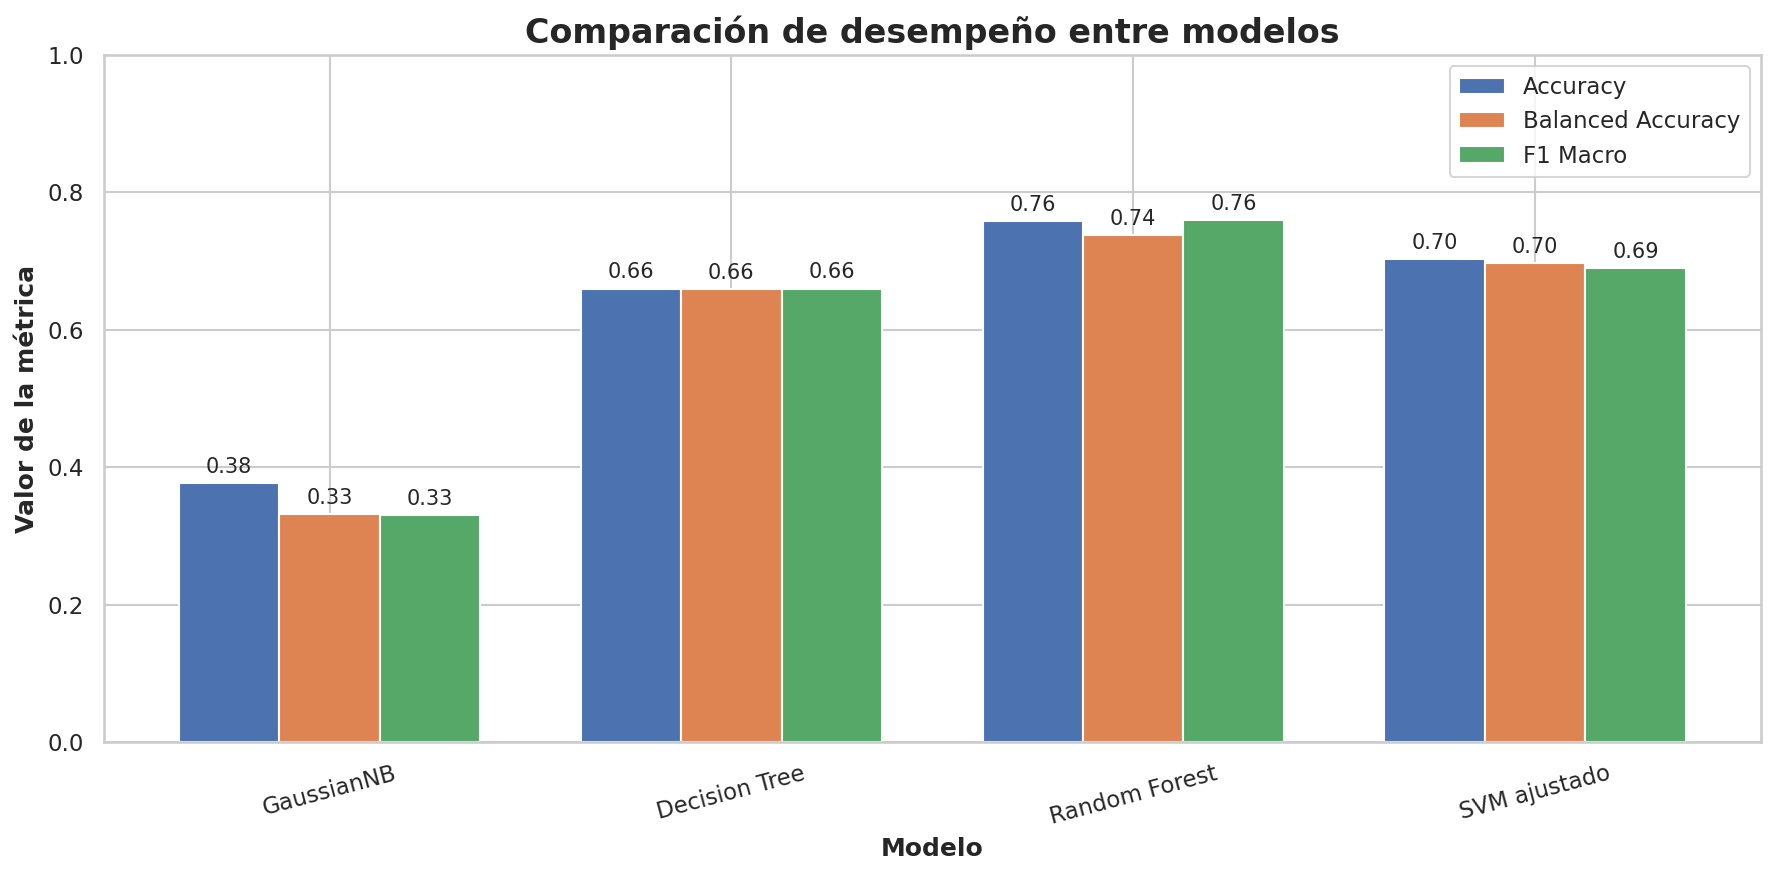

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

modelos = df_modelos["Modelo"]
x = np.arange(len(modelos))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, df_modelos["Accuracy"], width=width, label="Accuracy")
plt.bar(x, df_modelos["Balanced Accuracy"], width=width, label="Balanced Accuracy")
plt.bar(x + width, df_modelos["F1 Macro"], width=width, label="F1 Macro")

plt.title("Comparación de desempeño entre modelos", fontsize=16, fontweight="bold")
plt.xlabel("Modelo", fontsize=12, fontweight="bold")
plt.ylabel("Valor de la métrica", fontsize=12, fontweight="bold")
plt.xticks(x, modelos, rotation=15)
plt.ylim(0, 1)
plt.legend()

# Etiquetas encima de cada barra
for i in range(len(modelos)):
    plt.text(x[i] - width, df_modelos["Accuracy"][i] + 0.015, f"{df_modelos['Accuracy'][i]:.2f}", ha="center", fontsize=10)
    plt.text(x[i], df_modelos["Balanced Accuracy"][i] + 0.015, f"{df_modelos['Balanced Accuracy'][i]:.2f}", ha="center", fontsize=10)
    plt.text(x[i] + width, df_modelos["F1 Macro"][i] + 0.015, f"{df_modelos['F1 Macro'][i]:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

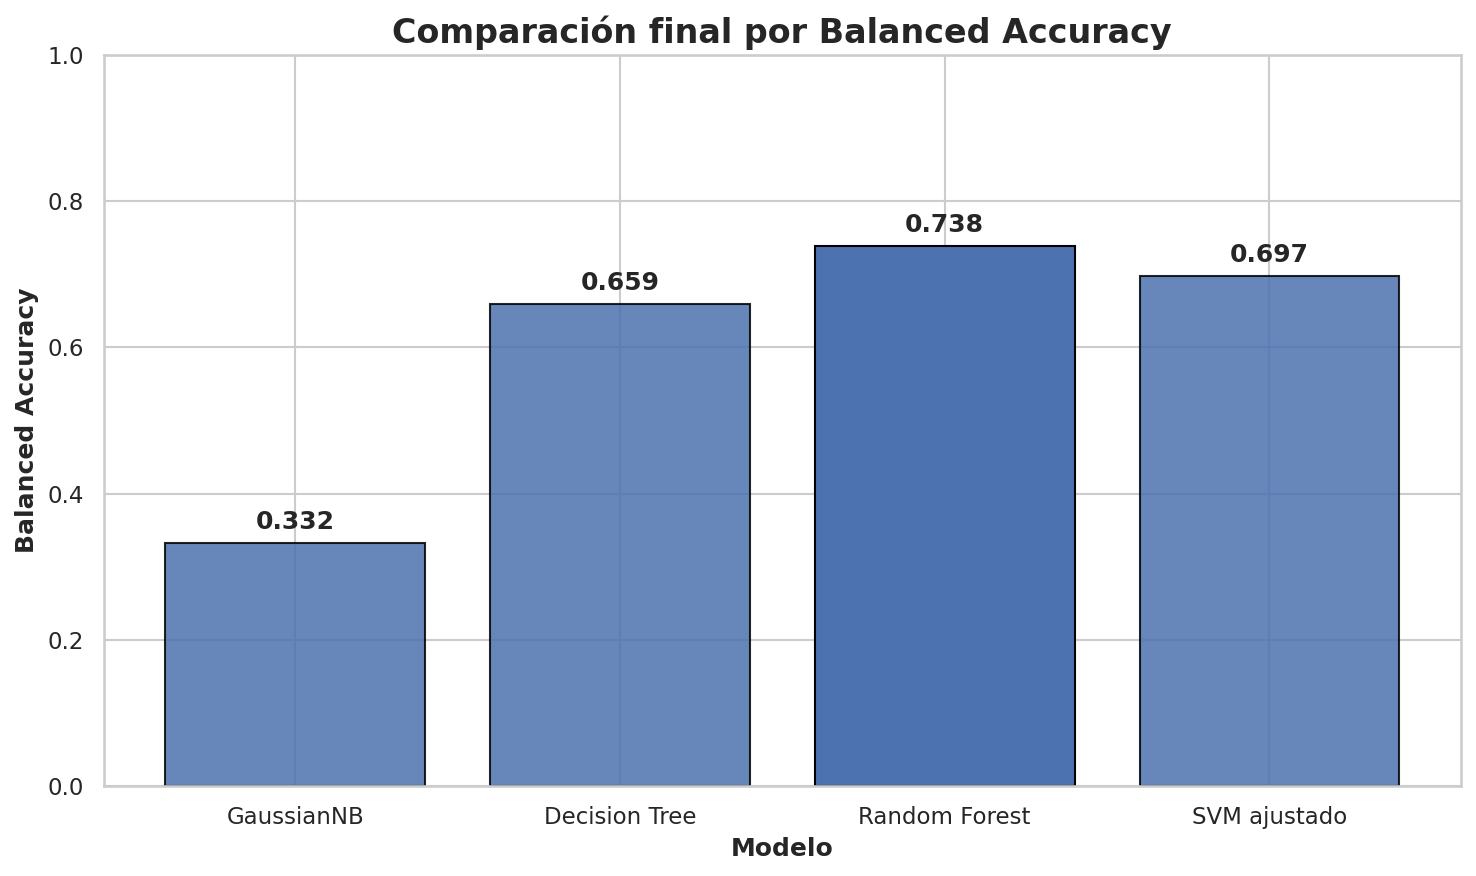

In [ ]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    df_modelos["Modelo"],
    df_modelos["Balanced Accuracy"],
    edgecolor="black",
    alpha=0.85
)

# Resaltar el mejor modelo
mejor_idx = df_modelos["Balanced Accuracy"].idxmax()
bars[mejor_idx].set_alpha(1.0)

plt.title("Comparación final por Balanced Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Modelo", fontsize=12, fontweight="bold")
plt.ylabel("Balanced Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)

for i, v in enumerate(df_modelos["Balanced Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()